In [47]:
# ── Cell 1: Imports + save helper ─────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import scipy.io as sio
from scipy.optimize import curve_fit
import warnings

import RamanHelpers as rh

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.dpi"       : 150,
    "axes.grid"        : False,   # off for spatial maps — grid lines are distracting
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Save helper ───────────────────────────────────────────────────────────────
SAVE_FILE = "map_results.npz"

def save_results(**kwargs):
    """
    Incrementally update map_results.npz.
    Loads existing data first so no previous results are lost.
    """
    store = dict(np.load(SAVE_FILE, allow_pickle=True)) \
            if os.path.exists(SAVE_FILE) else {}
    store.update(kwargs)
    np.savez(SAVE_FILE, **store)
    keys = list(kwargs.keys())
    print(f"  ✓ Saved {len(keys)} variable(s) → {SAVE_FILE}")
    print(f"    {keys}")

print("Imports OK")
print(f"Save file  : {SAVE_FILE}")
print(f"rh version : {rh.__file__}")

Imports OK
Save file  : map_results.npz
rh version : /Users/egeeroglu/Desktop/RIRO/Tuesday/RamanData/RamanHelpers.py


In [48]:
# ── Cell 2: Spatial parameters + load prior results ───────────────────────────
# This cell establishes the physical coordinate system for all maps
# and loads the single-spectrum fit results and calibration offset
# computed in the main analysis notebook.
#
# WHY THIS CELL EXISTS:
# Every map needs to know:
#   (a) how to convert spectrum index → physical position (µm)
#   (b) the calibration offset to correct all peak centres
#   (c) the laser spot size to contextualise spatial resolution
# Defining everything here in one place means no magic numbers
# are scattered across the map cells.

# ── Grid geometry (from GrapheneMap20Messposition.ompc) ───────────────────────
NX         = 20
NY         = 20
N_SPEC     = NX * NY             # 400 total spectra
STEP_X_UM  = 83.123894 / NX      # 4.156 µm per pixel in X
STEP_Y_UM  = 93.966141 / NY      # 4.698 µm per pixel in Y
EXTENT     = [0, NX * STEP_X_UM, NY * STEP_Y_UM, 0]  # for imshow

# Scan order: X-fast (row-major)
# spectrum index i → col = i % NX,  row = i // NX
# Confirmed from .ompc: X increments across all 20 cols before Y steps down

print(f"── Grid geometry ─────────────────────────────────────────────────────")
print(f"  Grid       : {NX} × {NY} = {N_SPEC} spectra")
print(f"  Step X     : {STEP_X_UM:.4f} µm/pixel")
print(f"  Step Y     : {STEP_Y_UM:.4f} µm/pixel")
print(f"  Total area : {NX*STEP_X_UM:.2f} × {NY*STEP_Y_UM:.2f} µm")

# ── Load calibration offset from calibration notebook ─────────────────────────
CAL_FILE = "calibration_results.npz"
if not os.path.exists(CAL_FILE):
    raise FileNotFoundError(
        f"{CAL_FILE} not found.\n"
        f"Run the calibration notebook first."
    )
cal       = np.load(CAL_FILE, allow_pickle=True)
CAL_OFFSET = float(cal["cal_offset"])
print(f"\n── Calibration ───────────────────────────────────────────────────────")
print(f"  CAL_OFFSET : {CAL_OFFSET:+.4f} cm⁻¹  (from GrapheneMap20 Si peak)")
print(f"  Applied to : all fitted peak centres across all 400 spectra")

# ── Load laser spot size from linescan notebook ───────────────────────────────
LS_FILE = "linescan_results.npz"
if os.path.exists(LS_FILE):
    ls         = np.load(LS_FILE, allow_pickle=True)
    FWHM_SPOT  = float(ls["ls_best_fwhm"])
    W_1E2      = float(ls["ls_best_w_1e2"])
    W_ERR      = float(ls["ls_best_w_err"])
else:
    print("  ⚠ linescan_results.npz not found — using fallback spot size")
    FWHM_SPOT  = 1.309    # µm, from Araújo analysis
    W_1E2      = 1.112    # µm
    W_ERR      = 0.032    # µm

A_PIXEL_UM2 = STEP_X_UM * STEP_Y_UM
A_SPOT_UM2  = np.pi * (FWHM_SPOT / 2)**2
NYQUIST     = STEP_X_UM / FWHM_SPOT

print(f"\n── Spatial resolution ────────────────────────────────────────────────")
print(f"  Laser FWHM      : {FWHM_SPOT:.3f} ± {W_ERR:.3f} µm")
print(f"  Laser 1/e² rad  : {W_1E2:.3f} µm")
print(f"  Step / FWHM     : {NYQUIST:.1f}×  → spatially independent pixels")
print(f"  Pixel area      : {A_PIXEL_UM2:.2f} µm²")
print(f"  Spot area       : {A_SPOT_UM2:.2f} µm²")
print(f"  Fill factor     : {100*A_SPOT_UM2/A_PIXEL_UM2:.1f}%  of pixel area illuminated")

# ── Load single-spectrum results from main analysis notebook ──────────────────
# These are the fit results for the best representative spectrum (idx_best).
# Used as reference values and initial guesses for the map fitting loop.
FIT_FILE = "fit_results.npz"
if not os.path.exists(FIT_FILE):
    raise FileNotFoundError(
        f"{FIT_FILE} not found.\n"
        f"Run the main analysis notebook first."
    )
fit      = np.load(FIT_FILE, allow_pickle=True)

# Reference values from best spectrum — used as p0 seeds for map fits
REF_G_CEN   = float(fit["g_cen_raw"])      # raw G centre (before cal correction)
REF_G_FWHM  = float(fit["g_fwhm"])
REF_TD_CEN  = float(fit["td_cen_raw"])     # raw 2D centre
REF_TD_FWHM = float(fit["td_fwhm"])
REF_D_CEN   = float(fit["d_cen_raw"])      # raw D centre
REF_D_FWHM  = float(fit["d_fwhm"])
IDX_BEST    = int(fit["idx_best"])
MONO_RATIO  = float(fit["td_classify_mono_ratio"])   # 1.0 — sample-specific

print(f"\n── Reference values (from spectrum {IDX_BEST}) ───────────────────────")
print(f"  G  centre (raw)  : {REF_G_CEN:.2f} cm⁻¹   FWHM: {REF_G_FWHM:.2f} cm⁻¹")
print(f"  2D centre (raw)  : {REF_TD_CEN:.2f} cm⁻¹  FWHM: {REF_TD_FWHM:.2f} cm⁻¹")
print(f"  D  centre (raw)  : {REF_D_CEN:.2f} cm⁻¹   FWHM: {REF_D_FWHM:.2f} cm⁻¹")
print(f"  mono_ratio       : {MONO_RATIO}  (sample-specific threshold)")

── Grid geometry ─────────────────────────────────────────────────────
  Grid       : 20 × 20 = 400 spectra
  Step X     : 4.1562 µm/pixel
  Step Y     : 4.6983 µm/pixel
  Total area : 83.12 × 93.97 µm

── Calibration ───────────────────────────────────────────────────────
  CAL_OFFSET : +1.0809 cm⁻¹  (from GrapheneMap20 Si peak)
  Applied to : all fitted peak centres across all 400 spectra

── Spatial resolution ────────────────────────────────────────────────
  Laser FWHM      : 1.309 ± 0.032 µm
  Laser 1/e² rad  : 1.112 µm
  Step / FWHM     : 3.2×  → spatially independent pixels
  Pixel area      : 19.53 µm²
  Spot area       : 1.35 µm²
  Fill factor     : 6.9%  of pixel area illuminated

── Reference values (from spectrum 134) ───────────────────────
  G  centre (raw)  : 1589.40 cm⁻¹   FWHM: 19.38 cm⁻¹
  2D centre (raw)  : 2685.89 cm⁻¹  FWHM: 24.67 cm⁻¹
  D  centre (raw)  : 1341.36 cm⁻¹   FWHM: 27.68 cm⁻¹
  mono_ratio       : 1.0  (sample-specific threshold)


In [49]:
# ── Cell 2b: Unpack all saved map results into named variables ─────────────────
if not os.path.exists(SAVE_FILE):
    print("⚠ map_results.npz not found — run Cell 3b first")
else:
    _store = dict(np.load(SAVE_FILE, allow_pickle=True))
    for _key, _val in _store.items():
        globals()[_key] = _val
    print(f"── Unpacked {len(_store)} variables from {SAVE_FILE} ──────────────")

    # ── Envelope FWHM ─────────────────────────────────────────────────────
    if "map_td_fwhm" in _store and "map_td_split" in _store:
        map_td_fwhm_envelope = map_td_fwhm.copy()
        model_B_mask = map_td_model == 2
        if np.any(model_B_mask):
            map_td_fwhm_envelope[model_B_mask] = (
                map_td_fwhm[model_B_mask] +
                map_td_split[model_B_mask])

    # ── Derived ratios ─────────────────────────────────────────────────────
    if "map_td_amp" in _store and "map_g_amp" in _store:
        map_ratio_2dg_amp  = map_td_amp  / map_g_amp
        map_ratio_2dg_area = map_td_area / map_g_area
        map_ratio_dg_amp   = map_d_amp   / map_g_amp
        map_ratio_dg_area  = map_d_area  / map_g_area

    # ── G and 2D reference values ──────────────────────────────────────────
    if "map_g_cen" in _store:
        g_valid     = map_g_cen[~np.isnan(map_g_cen)]
        g_median    = float(np.median(g_valid))
        g_std       = float(np.std(g_valid))
        g_vmin      = g_median - 2 * g_std
        g_vmax      = g_median + 2 * g_std
        g_deviation = map_g_cen - g_median

    if "map_td_cen" in _store:
        td_valid     = map_td_cen[~np.isnan(map_td_cen)]
        td_median    = float(np.median(td_valid))
        td_std       = float(np.std(td_valid))
        td_vmin      = td_median - 2 * td_std
        td_vmax      = td_median + 2 * td_std
        td_deviation = map_td_cen - td_median

    # ── G vs 2D spatial correlation ───────────────────────────────────────
    if "map_g_cen" in _store and "map_td_cen" in _store:
        _both = ~np.isnan(map_g_cen) & ~np.isnan(map_td_cen)
        _gd   = (map_g_cen  - g_median)[_both]
        _tdd  = (map_td_cen - td_median)[_both]
        map_corr_G_2D  = float(np.corrcoef(_gd, _tdd)[0, 1])
        map_slope_2D_G = float(np.polyfit(_gd, _tdd, 1)[0])

    # ── Error propagation quantities ───────────────────────────────────────
    # Recompute sigma_strain and sigma_doping if error arrays exist
    if ("map_g_cen_err" in _store and
        "map_td_cen_err" in _store and
        "map_strain_pct" in _store):

        SLOPE_STRAIN = 2.2;   SLOPE_DOPING = 0.7
        GAMMA_G      = 57.3;  DOPING_SLOPE = 42.0

        strain_vec = np.array([1.0, SLOPE_STRAIN])
        strain_vec = strain_vec / np.linalg.norm(strain_vec)
        doping_vec = np.array([1.0, SLOPE_DOPING])
        doping_vec = doping_vec / np.linalg.norm(doping_vec)

        map_sigma_strain = np.sqrt(
            (strain_vec[0] * map_g_cen_err)**2 +
            (strain_vec[1] * map_td_cen_err)**2
        ) * strain_vec[0] / GAMMA_G

        map_sigma_doping = np.sqrt(
            (doping_vec[0] * map_g_cen_err)**2 +
            (doping_vec[1] * map_td_cen_err)**2
        ) * doping_vec[0] / DOPING_SLOPE

    print(f"\n── Derived quantities recomputed ─────────────────────────────────")
    print(f"  map_td_fwhm_envelope : ✓")
    print(f"  map_ratio_2dg_amp    : ✓")
    print(f"  g_median             : {g_median:.3f} cm⁻¹")
    print(f"  td_median            : {td_median:.3f} cm⁻¹")
    print(f"  map_corr_G_2D        : {map_corr_G_2D:.3f}")
    print(f"  map_slope_2D_G       : {map_slope_2D_G:.3f}")
    if "map_sigma_strain" in dir():
        print(f"  map_sigma_strain     : "
              f"mean={np.nanmean(map_sigma_strain)*100:.4f} ×10⁻²%")
        print(f"  map_sigma_doping     : "
              f"mean={np.nanmean(map_sigma_doping):.4f} ×10¹³ cm⁻²")

── Unpacked 120 variables from map_results.npz ──────────────

── Derived quantities recomputed ─────────────────────────────────
  map_td_fwhm_envelope : ✓
  map_ratio_2dg_amp    : ✓
  g_median             : 1588.190 cm⁻¹
  td_median            : 2680.884 cm⁻¹
  map_corr_G_2D        : 0.121
  map_slope_2D_G       : 0.110


### All important and spotted peaks to be fitted: ###

In [50]:
# ── Cell 3a: Map fitting helpers ──────────────────────────────────────────────
# All functions needed for the 400-spectrum fitting loop.
# Defined here separately so Cell 3b (the loop) stays readable.
# None of these are in rh because they are map-loop specific —
# they need to be fast, minimal, and tailored to batch processing.

# ── Two-Lorentzian lineshape ───────────────────────────────────────────────────
def two_lorentzians(x, a1, c1, f1, a2, c2, f2):
    return rh.lorentzian(x, a1, c1, f1) + rh.lorentzian(x, a2, c2, f2)

# ── Three-Lorentzian lineshape (Si 2TO) ───────────────────────────────────────
def three_lorentzians(x, a1, c1, f1, a2, c2, f2, a3, c3, f3):
    return (rh.lorentzian(x, a1, c1, f1) +
            rh.lorentzian(x, a2, c2, f2) +
            rh.lorentzian(x, a3, c3, f3))

# ── Model A vs B selector (single → double) ───────────────────────────────────
def model_select(wn_fit, sp_fit, popt_A, p0_B, bounds_B,
                 threshold=0.10, min_fwhm=3.0, min_amp_frac=0.05):
    """
    Compare single Lorentzian (Model A) vs two Lorentzians (Model B).
    Returns (popt_best, model_code):
        model_code 1 = single (Model A)
        model_code 2 = double (Model B)

    Model B is chosen only if:
      (a) RMS improves by > threshold (default 10%)
      (b) both components have FWHM > min_fwhm
      (c) weaker component amplitude > min_amp_frac × stronger component
    """
    fit_A = rh.lorentzian(wn_fit, *popt_A)
    rms_A = np.sqrt(np.mean((sp_fit - fit_A)**2))
    try:
        popt_B, _ = curve_fit(two_lorentzians, wn_fit, sp_fit,
                              p0=p0_B, bounds=bounds_B, maxfev=6000)
        fit_B       = two_lorentzians(wn_fit, *popt_B)
        rms_B       = np.sqrt(np.mean((sp_fit - fit_B)**2))
        improvement = (rms_A - rms_B) / rms_A
        physical    = (popt_B[2] > min_fwhm and
                       popt_B[5] > min_fwhm and
                       popt_B[3] > min_amp_frac * popt_B[0])
        if improvement > threshold and physical:
            return popt_B, 2
    except RuntimeError:
        pass
    return popt_A, 1


# ── Model A vs B vs C selector (single → triple, for Si 2TO) ─────────────────
def triple_model_select(wn_fit, sp_fit, popt_A, p0_B, bounds_B,
                        threshold=0.10):
    """
    Compare single Lorentzian (Model A) vs three Lorentzians (Model C)
    for the Si 2TO multiplet (2TO(X) ~935, 2TO(W) ~960, 2TO(L) ~985 cm⁻¹).

    Returns (amp, cen, fwhm, model_code, popt_full):
        model_code 1 = single  — popt_full is popt_A (3 params)
        model_code 3 = triple  — popt_full is popt_B (9 params)

    Representative component = dominant (highest amplitude) of the three.
    For Si 2TO this is almost always 2TO(W) at ~960 cm⁻¹.

    Model C chosen only if:
      (a) RMS improves by > threshold
      (b) all three components have FWHM > 3 cm⁻¹
      (c) all three components have positive amplitude
    """
    fit_A = rh.lorentzian(wn_fit, *popt_A)
    rms_A = np.sqrt(np.mean((sp_fit - fit_A)**2))

    try:
        popt_B, _ = curve_fit(three_lorentzians, wn_fit, sp_fit,
                              p0=p0_B, bounds=bounds_B, maxfev=10000)
        fit_B       = three_lorentzians(wn_fit, *popt_B)
        rms_B       = np.sqrt(np.mean((sp_fit - fit_B)**2))
        improvement = (rms_A - rms_B) / rms_A

        # Unpack three components: (a1,c1,f1), (a2,c2,f2), (a3,c3,f3)
        amps  = [popt_B[0], popt_B[3], popt_B[6]]
        fwhms = [popt_B[2], popt_B[5], popt_B[8]]
        physical = (all(f > 3.0 for f in fwhms) and
                    all(a > 0.0 for a in amps))

        if improvement > threshold and physical:
            # Representative = dominant component (highest amplitude)
            idx_dom  = int(np.argmax(amps))
            amp_rep  = popt_B[idx_dom * 3]
            cen_rep  = popt_B[idx_dom * 3 + 1]
            fwhm_rep = popt_B[idx_dom * 3 + 2]
            return amp_rep, cen_rep, fwhm_rep, 3, popt_B

    except RuntimeError:
        pass

    # Fall back to single
    return popt_A[0], popt_A[1], popt_A[2], 1, popt_A


# ── Component extraction helpers ──────────────────────────────────────────────

def stronger_component(popt, model_code):
    """
    Extract representative (stronger) component from a fit result.
    model_code 1 → single: returns (amp, cen, fwhm) directly.
    model_code 2 → double: returns the higher-amplitude component.
    """
    if model_code == 1:
        return popt[0], popt[1], popt[2]
    return (popt[0], popt[1], popt[2]) if popt[0] >= popt[3] \
           else (popt[3], popt[4], popt[5])


def main_d_component(popt, model_code):
    """
    For D band specifically: main D = higher wavenumber component.
    D⁻ shoulder sits BELOW main D (~1320 cm⁻¹) — strain / heavy defects.
    D⁺ shoulder sits ABOVE main D (~1370 cm⁻¹) — oxidation / functionalisation.
    Main D band is always the component with the higher centre position.
    """
    if model_code == 1:
        return popt[0], popt[1], popt[2]
    # Higher centre wavenumber = main D band
    return (popt[0], popt[1], popt[2]) if popt[1] >= popt[4] \
           else (popt[3], popt[4], popt[5])


# ── Fit window and p0 definitions ─────────────────────────────────────────────
# All crop ranges, baseline anchors, initial guesses, and bounds
# defined here using reference values from the single best spectrum.
# This avoids repeating magic numbers in the loop.
#
# Keys per band:
#   lo, hi          — crop window (cm⁻¹)
#   bl_lo, bl_hi    — baseline anchor positions (cm⁻¹)
#   p0_fn           — lambda(sp, wn) → initial guess [amp, cen, fwhm]
#   bounds          — ([lower], [upper]) for Model A
#   p0_B_fn         — lambda(popt_A) → p0 for Model B  (optional)
#   bounds_B        — bounds for Model B                (optional)
#   triple          — True if Model B uses three_lorentzians (optional)

FIT_CFG = {

    # ── Si peak (~521 cm⁻¹) ───────────────────────────────────────────────────
    "si": dict(
        lo=460, hi=580, bl_lo=490, bl_hi=550,
        p0_fn  = lambda sp, wn: [sp[(wn>=500)&(wn<=540)].max(), 521, 5],
        bounds = ([0, 500, 1], [np.inf, 540, 30]),
    ),

    # ── D band (~1350 cm⁻¹) ───────────────────────────────────────────────────
    "d": dict(
        lo=1220, hi=1460, bl_lo=1260, bl_hi=1420,
        p0_fn  = lambda sp, wn: [sp[(wn>=1320)&(wn<=1380)].max(),
                                  REF_D_CEN, REF_D_FWHM],
        bounds = ([0, 1300, 10], [np.inf, 1400, 120]),
        p0_B_fn  = lambda pA: [pA[0], pA[1], pA[2],
                                pA[0]*0.3, pA[1]+20, pA[2]*0.7],
        bounds_B = ([0, 1290, 5,  0, 1310, 5],
                    [np.inf, 1370, 100, np.inf, 1400, 100]),
    ),

    # ── G band (~1580 cm⁻¹) ───────────────────────────────────────────────────
    "g": dict(
        lo=1450, hi=1710, bl_lo=1490, bl_hi=1670,
        p0_fn  = lambda sp, wn: [sp[(wn>=1560)&(wn<=1610)].max(),
                                  REF_G_CEN, REF_G_FWHM],
        bounds = ([0, 1550, 3], [np.inf, 1620, 60]),
        p0_B_fn  = lambda pA: [pA[0], pA[1], pA[2],
                                pA[0]*0.1, 1625, 15],
        bounds_B = ([0, 1550, 3, 0, 1610, 3],
                    [np.inf, 1620, 50, np.inf, 1650, 40]),
    ),

    # ── 2D band (~2680 cm⁻¹) ──────────────────────────────────────────────────
    "td": dict(
        lo=2550, hi=2830, bl_lo=2590, bl_hi=2790,
        p0_fn  = lambda sp, wn: [sp[(wn>=2640)&(wn<=2740)].max(),
                                  REF_TD_CEN, REF_TD_FWHM],
        bounds = ([0, 2620, 10], [np.inf, 2760, 100]),
        p0_B_fn  = lambda pA: [pA[0], pA[1], pA[2],
                                pA[0]*0.4, pA[1]+15, pA[2]],
        bounds_B = ([0, 2620, 5,  0, 2640, 5],
                    [np.inf, 2730, 80, np.inf, 2760, 80]),
    ),

    # ── D+D" combination (~2450 cm⁻¹) ────────────────────────────────────────
    "ddp": dict(
        lo=2370, hi=2610, bl_lo=2410, bl_hi=2570,
        p0_fn  = lambda sp, wn: [sp[(wn>=2420)&(wn<=2540)].max(), 2450, 40],
        bounds = ([0, 2400, 10], [np.inf, 2560, 120]),
    ),

    # ── 2D' overtone (~3270 cm⁻¹) ────────────────────────────────────────────
    "tdp": dict(
        lo=3120, hi=3430, bl_lo=3160, bl_hi=3390,
        p0_fn  = lambda sp, wn: [sp[(wn>=3200)&(wn<=3350)].max(), 3270, 40],
        bounds = ([0, 3180, 10], [np.inf, 3380, 120]),
    ),

    # ── Si 2TO overtone (~960 cm⁻¹) ───────────────────────────────────────────
    "si2to": dict(
        lo=850, hi=1080, bl_lo=890, bl_hi=1040,
        p0_fn  = lambda sp, wn: [sp[(wn>=930)&(wn<=1000)].max(), 960, 60],
        bounds = ([0, 920, 20], [np.inf, 1000, 150]),
        p0_B_fn  = lambda pA: [pA[0]*0.6, 935, 25,
                                pA[0],     960, 25,
                                pA[0]*0.4, 985, 25],
        bounds_B = ([0, 910, 5,  0, 940, 5,  0, 965, 5],
                    [np.inf, 945, 60, np.inf, 975, 60, np.inf, 1005, 60]),
        triple   = True,
    ),

    # ── Contamination feature (~1407 cm⁻¹) ───────────────────────────────────
    "contam": dict(
        lo=1335, hi=1465, bl_lo=1355, bl_hi=1445,
        p0_fn  = lambda sp, wn: [sp[(wn>=1395)&(wn<=1420)].max(), 1407, 15],
        bounds = ([0, 1390, 3], [np.inf, 1430, 40]),
    ),
}

# ── Verify all baseline windows now fall inside crop windows ──────────────────
print("── Baseline window check ─────────────────────────────────────────────")
width = 20
all_ok = True
for band, cfg in FIT_CFG.items():
    lo, hi       = cfg["lo"], cfg["hi"]
    bl_lo, bl_hi = cfg["bl_lo"], cfg["bl_hi"]
    left_ok  = (bl_lo - width) >= lo  and bl_lo        <= hi
    right_ok = bl_hi             >= lo and (bl_hi + width) <= hi
    status   = "✓" if (left_ok and right_ok) else "✗ PROBLEM"
    if not (left_ok and right_ok):
        all_ok = False
    print(f"  {band:<8} crop=[{lo},{hi}]  "
          f"left=[{bl_lo-width},{bl_lo}]  "
          f"right=[{bl_hi},{bl_hi+width}]  {status}")

print()
if all_ok:
    print("  All baseline windows are inside their crop windows ✓")
else:
    print("  ✗ Fix the flagged bands before running Cell 3b")

# ── Print model summary ───────────────────────────────────────────────────────
print("\n── Fit configuration ─────────────────────────────────────────────────")
for band, cfg in FIT_CFG.items():
    has_B     = "p0_B_fn" in cfg
    is_triple = cfg.get("triple", False)
    if is_triple:
        model_str = "Model A + triple (3 Lorentzians)"
    elif has_B:
        model_str = "Model A + B      (2 Lorentzians)"
    else:
        model_str = "Model A only     (1 Lorentzian) "
    print(f"  {band:<8} : {cfg['lo']:4.0f}–{cfg['hi']:4.0f} cm⁻¹  {model_str}")

── Baseline window check ─────────────────────────────────────────────
  si       crop=[460,580]  left=[470,490]  right=[550,570]  ✓
  d        crop=[1220,1460]  left=[1240,1260]  right=[1420,1440]  ✓
  g        crop=[1450,1710]  left=[1470,1490]  right=[1670,1690]  ✓
  td       crop=[2550,2830]  left=[2570,2590]  right=[2790,2810]  ✓
  ddp      crop=[2370,2610]  left=[2390,2410]  right=[2570,2590]  ✓
  tdp      crop=[3120,3430]  left=[3140,3160]  right=[3390,3410]  ✓
  si2to    crop=[850,1080]  left=[870,890]  right=[1040,1060]  ✓
  contam   crop=[1335,1465]  left=[1335,1355]  right=[1445,1465]  ✓

  All baseline windows are inside their crop windows ✓

── Fit configuration ─────────────────────────────────────────────────
  si       :  460– 580 cm⁻¹  Model A only     (1 Lorentzian) 
  d        : 1220–1460 cm⁻¹  Model A + B      (2 Lorentzians)
  g        : 1450–1710 cm⁻¹  Model A + B      (2 Lorentzians)
  td       : 2550–2830 cm⁻¹  Model A + B      (2 Lorentzians)
  ddp      : 2370–

In [51]:
# ── Safety initialisations — in case Cell 3a hasn't run ───────────────────────
if "IMPROVEMENT_THRESHOLD" not in dir():
    IMPROVEMENT_THRESHOLD = 0.10
    print("⚠ IMPROVEMENT_THRESHOLD not found — using default 0.10")
if "two_lorentzians" not in dir():
    raise RuntimeError(
        "Fitting helpers not defined — run Cell 3a first.\n"
        "Cell 3b depends on: two_lorentzians, three_lorentzians, "
        "model_select, triple_model_select, stronger_component, "
        "main_d_component, FIT_CFG"
    )

In [52]:
# ── Cell 3b: Full fitting loop — all bands, all 400 spectra ───────────────────

# ── Safety initialisations ────────────────────────────────────────────────────
if "IMPROVEMENT_THRESHOLD" not in dir():
    IMPROVEMENT_THRESHOLD = 0.10
    print("⚠ IMPROVEMENT_THRESHOLD not found — using default 0.10")
if "two_lorentzians" not in dir():
    raise RuntimeError("Fitting helpers not defined — run Cell 3a first.")

FORCE_REFIT = True

THRESHOLDS = {
    "d"  : IMPROVEMENT_THRESHOLD,
    "g"  : IMPROVEMENT_THRESHOLD,
    "td" : 0.40,
}

BANDS = ["si", "d", "g", "td", "ddp", "tdp", "si2to", "contam"]

# ── Check if fits already exist ───────────────────────────────────────────────
fits_exist = (not FORCE_REFIT and
              os.path.exists(SAVE_FILE) and
              "map_g_amp" in np.load(SAVE_FILE, allow_pickle=True))

if fits_exist:
    print("── Loading existing map fits from map_results.npz ────────────────")
    prev    = np.load(SAVE_FILE, allow_pickle=True)
    results = {}
    for band in BANDS:
        for qty in ["amp", "cen", "fwhm", "area", "model"]:
            key = f"map_{band}_{qty}"
            if key in prev:
                results[key] = prev[key]
    for key in ["map_td_cen_B1", "map_td_cen_B2",
                "map_td_fwhm_B1", "map_td_fwhm_B2",
                "map_td_amp_B1",  "map_td_amp_B2",
                "map_td_split",
                "map_g_cen_err",  "map_td_cen_err",
                "map_d_cen_err"]:
        if key in prev:
            results[key] = prev[key]
    print(f"  Loaded bands : {BANDS}")

else:
    print("── Fitting all 400 spectra ───────────────────────────────────────")
    print(f"  Bands        : {BANDS}")
    print(f"  Model A+B    : d (10%), g (10%), td (40%)")
    print(f"  Model A+C    : si2to  (triple, {IMPROVEMENT_THRESHOLD*100:.0f}%)")
    print(f"  Model A only : si, ddp, tdp, contam")
    print(f"  CAL_OFFSET   : {CAL_OFFSET:+.4f} cm⁻¹  applied to all centres")
    print(f"  FORCE_REFIT  : {FORCE_REFIT}\n")

    mat     = sio.loadmat("GrapheneMap20.0.mat")
    Ra      = mat["Ra"]
    wn      = Ra[:, 0]
    spectra = Ra[:, 1:]
    print(f"  Loaded : {spectra.shape[1]} spectra  "
          f"({wn.min():.0f}–{wn.max():.0f} cm⁻¹)")

    # ── Pre-allocate standard result arrays ────────────────────────────────
    results = {}
    for band in BANDS:
        for qty in ["amp", "cen", "fwhm", "area"]:
            results[f"map_{band}_{qty}"] = np.full(N_SPEC, np.nan)
        results[f"map_{band}_model"] = np.zeros(N_SPEC, dtype=int)

    # ── Pre-allocate td two-component arrays ──────────────────────────────
    results["map_td_cen_B1"]  = np.full(N_SPEC, np.nan)
    results["map_td_cen_B2"]  = np.full(N_SPEC, np.nan)
    results["map_td_fwhm_B1"] = np.full(N_SPEC, np.nan)
    results["map_td_fwhm_B2"] = np.full(N_SPEC, np.nan)
    results["map_td_amp_B1"]  = np.full(N_SPEC, np.nan)
    results["map_td_amp_B2"]  = np.full(N_SPEC, np.nan)
    results["map_td_split"]   = np.full(N_SPEC, np.nan)

    # ── Pre-allocate centre uncertainty arrays ────────────────────────────
    # 1-sigma from Model A covariance matrix — used for error propagation
    # in strain/doping decomposition (Map 6)
    results["map_g_cen_err"]  = np.full(N_SPEC, np.nan)
    results["map_td_cen_err"] = np.full(N_SPEC, np.nan)
    results["map_d_cen_err"]  = np.full(N_SPEC, np.nan)

    # ── Main fitting loop ──────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for i in range(N_SPEC):
            sp = spectra[:, i]

            if i % 50 == 0:
                pct   = 100 * i / N_SPEC
                g_ok  = int(np.sum(~np.isnan(results["map_g_amp"][:i])))
                td_ok = int(np.sum(~np.isnan(results["map_td_amp"][:i])))
                print(f"  [{pct:5.1f}%]  spectrum {i:3d}/{N_SPEC}  "
                      f"G:{g_ok}  2D:{td_ok}")

            for band in BANDS:
                cfg = FIT_CFG[band]
                try:
                    # ── Step 1: Crop + baseline ───────────────────────────
                    wn_b, sp_b = rh.crop(wn, sp, cfg["lo"], cfg["hi"])
                    bl_b       = rh.linear_baseline(
                                     wn_b, sp_b, cfg["bl_lo"], cfg["bl_hi"])
                    sp_bl      = sp_b - bl_b

                    # ── Step 2: Model A fit — capture covariance ──────────
                    # pcov_A gives uncertainties on (amp, cen, fwhm)
                    # perr_A[1] = 1-sigma on centre position
                    p0_A           = cfg["p0_fn"](sp, wn)
                    popt_A, pcov_A = curve_fit(
                        rh.lorentzian, wn_b, sp_bl,
                        p0=p0_A, bounds=cfg["bounds"], maxfev=4000)
                    perr_A = np.sqrt(np.diag(pcov_A))

                    # ── Step 3: Noise / validity gates ────────────────────
                    noise_gates = {
                        "d"     : (1200, 1280, 3.0),
                        "contam": (1355, 1380, 1.5),
                        "ddp"   : (2560, 2590, 2.0),
                        "tdp"   : (3380, 3420, 2.0),
                    }
                    if band in noise_gates:
                        lo_n, hi_n, mult = noise_gates[band]
                        _, sp_noise = rh.crop(wn, sp, lo_n, hi_n)
                        if popt_A[0] < mult * sp_noise.std():
                            raise RuntimeError(f"{band} below noise floor")

                    # ── Step 4: Model B / C selection ─────────────────────
                    is_triple = cfg.get("triple", False)
                    has_B     = "p0_B_fn" in cfg

                    if is_triple:
                        p0_B     = cfg["p0_B_fn"](popt_A)
                        bounds_B = cfg["bounds_B"]
                        amp, cen, fwhm, model_code, _ = triple_model_select(
                            wn_b, sp_bl, popt_A, p0_B, bounds_B,
                            threshold=IMPROVEMENT_THRESHOLD)

                    elif has_B:
                        p0_B      = cfg["p0_B_fn"](popt_A)
                        bounds_B  = cfg["bounds_B"]
                        threshold = THRESHOLDS.get(band, IMPROVEMENT_THRESHOLD)
                        popt, model_code = model_select(
                            wn_b, sp_bl, popt_A, p0_B, bounds_B,
                            threshold=threshold)

                        if band == "d":
                            amp, cen, fwhm = main_d_component(popt, model_code)
                        else:
                            amp, cen, fwhm = stronger_component(popt, model_code)

                        # Store td two-component parameters
                        if band == "td" and model_code == 2:
                            results["map_td_amp_B1"][i]  = popt[0]
                            results["map_td_cen_B1"][i]  = popt[1] - CAL_OFFSET
                            results["map_td_fwhm_B1"][i] = popt[2]
                            results["map_td_amp_B2"][i]  = popt[3]
                            results["map_td_cen_B2"][i]  = popt[4] - CAL_OFFSET
                            results["map_td_fwhm_B2"][i] = popt[5]
                            results["map_td_split"][i]   = abs(popt[4] - popt[1])

                    else:
                        amp, cen, fwhm = popt_A[0], popt_A[1], popt_A[2]
                        model_code     = 1

                    # ── Step 5: Store ──────────────────────────────────────
                    apply_cal = band not in ("si", "si2to")
                    results[f"map_{band}_amp"][i]   = amp
                    results[f"map_{band}_cen"][i]   = (cen - CAL_OFFSET
                                                        if apply_cal else cen)
                    results[f"map_{band}_fwhm"][i]  = fwhm
                    results[f"map_{band}_area"][i]  = amp * fwhm * np.pi / 2
                    results[f"map_{band}_model"][i] = model_code

                    # ── Step 6: Store centre uncertainties ────────────────
                    # Use Model A covariance — most reliable single estimate.
                    # perr_A[1] = 1-sigma on centre position (cm⁻¹)
                    if band == "g":
                        results["map_g_cen_err"][i]  = perr_A[1]
                    elif band == "td":
                        results["map_td_cen_err"][i] = perr_A[1]
                    elif band == "d":
                        results["map_d_cen_err"][i]  = perr_A[1]

                except RuntimeError:
                    pass

    # ── Fit summary ────────────────────────────────────────────────────────
    print(f"\n── Fit summary ───────────────────────────────────────────────────")
    print(f"  {'Band':<8}  {'Success':>8}  {'Model A':>8}  "
          f"{'Model B':>8}  {'Model C':>8}")
    print(f"  {'-'*50}")
    for band in BANDS:
        n_ok = int(np.sum(~np.isnan(results[f"map_{band}_amp"])))
        n_A  = int(np.sum(results[f"map_{band}_model"] == 1))
        n_B  = int(np.sum(results[f"map_{band}_model"] == 2))
        n_C  = int(np.sum(results[f"map_{band}_model"] == 3))
        thr  = f"({THRESHOLDS.get(band, IMPROVEMENT_THRESHOLD)*100:.0f}%)" \
               if band in THRESHOLDS else ""
        print(f"  {band:<8}  {n_ok:>5}/{N_SPEC}  "
              f"{n_A:>8}  {n_B:>8}  {n_C:>8}  {thr}")

    n_split = int(np.sum(~np.isnan(results["map_td_split"])))
    if n_split > 0:
        sp_vals = results["map_td_split"][~np.isnan(results["map_td_split"])]
        print(f"\n  td split (Model B, n={n_split}): "
              f"mean={sp_vals.mean():.1f}  "
              f"range=[{sp_vals.min():.1f}, {sp_vals.max():.1f}] cm⁻¹")
        print(f"    <20 cm⁻¹ strain-like : {np.sum(sp_vals<20)}/{n_split}")
        print(f"    ≥20 cm⁻¹ bilayer-like: {np.sum(sp_vals>=20)}/{n_split}")

    # Centre uncertainty summary
    for key, label in [("map_g_cen_err","G"), ("map_td_cen_err","2D"),
                        ("map_d_cen_err","D")]:
        v = results[key][~np.isnan(results[key])]
        if len(v) > 0:
            print(f"  {label} cen err: mean={v.mean():.4f}  "
                  f"max={v.max():.4f} cm⁻¹")

    save_results(**results)


# ── Unpack results → named variables ──────────────────────────────────────────
for band in BANDS:
    for qty in ["amp", "cen", "fwhm", "area", "model"]:
        key = f"map_{band}_{qty}"
        if key in results:
            globals()[key] = results[key]

for key in ["map_td_cen_B1", "map_td_cen_B2",
            "map_td_fwhm_B1", "map_td_fwhm_B2",
            "map_td_amp_B1",  "map_td_amp_B2",
            "map_td_split",
            "map_g_cen_err",  "map_td_cen_err",
            "map_d_cen_err"]:
    if key in results:
        globals()[key] = results[key]

# ── Envelope FWHM ──────────────────────────────────────────────────────────────
map_td_fwhm_envelope = map_td_fwhm.copy()
model_B_mask = map_td_model == 2
if np.any(model_B_mask) and "map_td_split" in dir():
    map_td_fwhm_envelope[model_B_mask] = (
        map_td_fwhm[model_B_mask] + map_td_split[model_B_mask])
    env_B = map_td_fwhm_envelope[model_B_mask]
    print(f"\n  Envelope FWHM (Model B): mean={env_B.mean():.1f}  "
          f"range=[{env_B.min():.1f}, {env_B.max():.1f}] cm⁻¹")

# ── Derived ratios ─────────────────────────────────────────────────────────────
map_ratio_2dg_amp  = map_td_amp  / map_g_amp
map_ratio_2dg_area = map_td_area / map_g_area
map_ratio_dg_amp   = map_d_amp   / map_g_amp
map_ratio_dg_area  = map_d_area  / map_g_area
map_dp_inferred    = map_tdp_cen / 2.0

# ── Layer classification ───────────────────────────────────────────────────────
valid_both = ~np.isnan(map_ratio_2dg_amp) & ~np.isnan(map_td_fwhm)
map_layer  = np.full(N_SPEC, 0, dtype=int)
map_layer[valid_both] = rh.classify_layer(
    ratio_2DG  = map_ratio_2dg_amp[valid_both],
    fwhm_2D    = map_td_fwhm_envelope[valid_both],
    mono_ratio = MONO_RATIO,
)[:]

# ── Ferrari Stage 1 ────────────────────────────────────────────────────────────
valid_d = ~np.isnan(map_d_amp) & ~np.isnan(map_g_amp)
map_LD1 = np.full(N_SPEC, np.nan)
map_nD1 = np.full(N_SPEC, np.nan)
map_LD1[valid_d], map_nD1[valid_d] = rh.ferrari_stage1(
    map_d_amp[valid_d], map_g_amp[valid_d], EL=2.33)

# ── Save derived quantities ────────────────────────────────────────────────────
save_results(
    map_td_fwhm_envelope = map_td_fwhm_envelope,
    map_ratio_2dg_amp    = map_ratio_2dg_amp,
    map_ratio_2dg_area   = map_ratio_2dg_area,
    map_ratio_dg_amp     = map_ratio_dg_amp,
    map_ratio_dg_area    = map_ratio_dg_area,
    map_dp_inferred      = map_dp_inferred,
    map_layer            = map_layer,
    map_LD1              = map_LD1,
    map_nD1              = map_nD1,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"\n── Sanity check ──────────────────────────────────────────────────────")
r  = map_ratio_2dg_amp[~np.isnan(map_ratio_2dg_amp)]
f  = map_td_fwhm[~np.isnan(map_td_fwhm)]
fe = map_td_fwhm_envelope[~np.isnan(map_td_fwhm_envelope)]
n  = map_nD1[~np.isnan(map_nD1)]
print(f"  I(2D)/I(G) amp   : mean={r.mean():.2f}  std={r.std():.2f}  "
      f"range=[{r.min():.2f}, {r.max():.2f}]")
print(f"  2D FWHM (comp)   : mean={f.mean():.1f}  std={f.std():.1f}  "
      f"range=[{f.min():.1f}, {f.max():.1f}] cm⁻¹")
print(f"  2D FWHM (envelop): mean={fe.mean():.1f}  std={fe.std():.1f}  "
      f"range=[{fe.min():.1f}, {fe.max():.1f}] cm⁻¹")
print(f"  n_D (cm⁻²)       : mean={n.mean():.2e}  "
      f"range=[{n.min():.2e}, {n.max():.2e}]")
print(f"  Monolayer        : {np.sum(map_layer==1)}/{N_SPEC} pixels  "
      f"({100*np.sum(map_layer==1)/N_SPEC:.0f}%)")
print(f"  Bilayer          : {np.sum(map_layer==2)}/{N_SPEC} pixels  "
      f"({100*np.sum(map_layer==2)/N_SPEC:.0f}%)")
print(f"  No signal        : {np.sum(map_layer==0)}/{N_SPEC} pixels")

── Fitting all 400 spectra ───────────────────────────────────────
  Bands        : ['si', 'd', 'g', 'td', 'ddp', 'tdp', 'si2to', 'contam']
  Model A+B    : d (10%), g (10%), td (40%)
  Model A+C    : si2to  (triple, 10%)
  Model A only : si, ddp, tdp, contam
  CAL_OFFSET   : +1.0809 cm⁻¹  applied to all centres
  FORCE_REFIT  : True

  Loaded : 400 spectra  (40–4450 cm⁻¹)
  [  0.0%]  spectrum   0/400  G:0  2D:0
  [ 12.5%]  spectrum  50/400  G:50  2D:50
  [ 25.0%]  spectrum 100/400  G:100  2D:100
  [ 37.5%]  spectrum 150/400  G:150  2D:150
  [ 50.0%]  spectrum 200/400  G:200  2D:200
  [ 62.5%]  spectrum 250/400  G:250  2D:250
  [ 75.0%]  spectrum 300/400  G:300  2D:300
  [ 87.5%]  spectrum 350/400  G:350  2D:350

── Fit summary ───────────────────────────────────────────────────
  Band       Success   Model A   Model B   Model C
  --------------------------------------------------
  si          400/400       400         0         0  
  d           400/400       164       236         0 

### Maps: ###

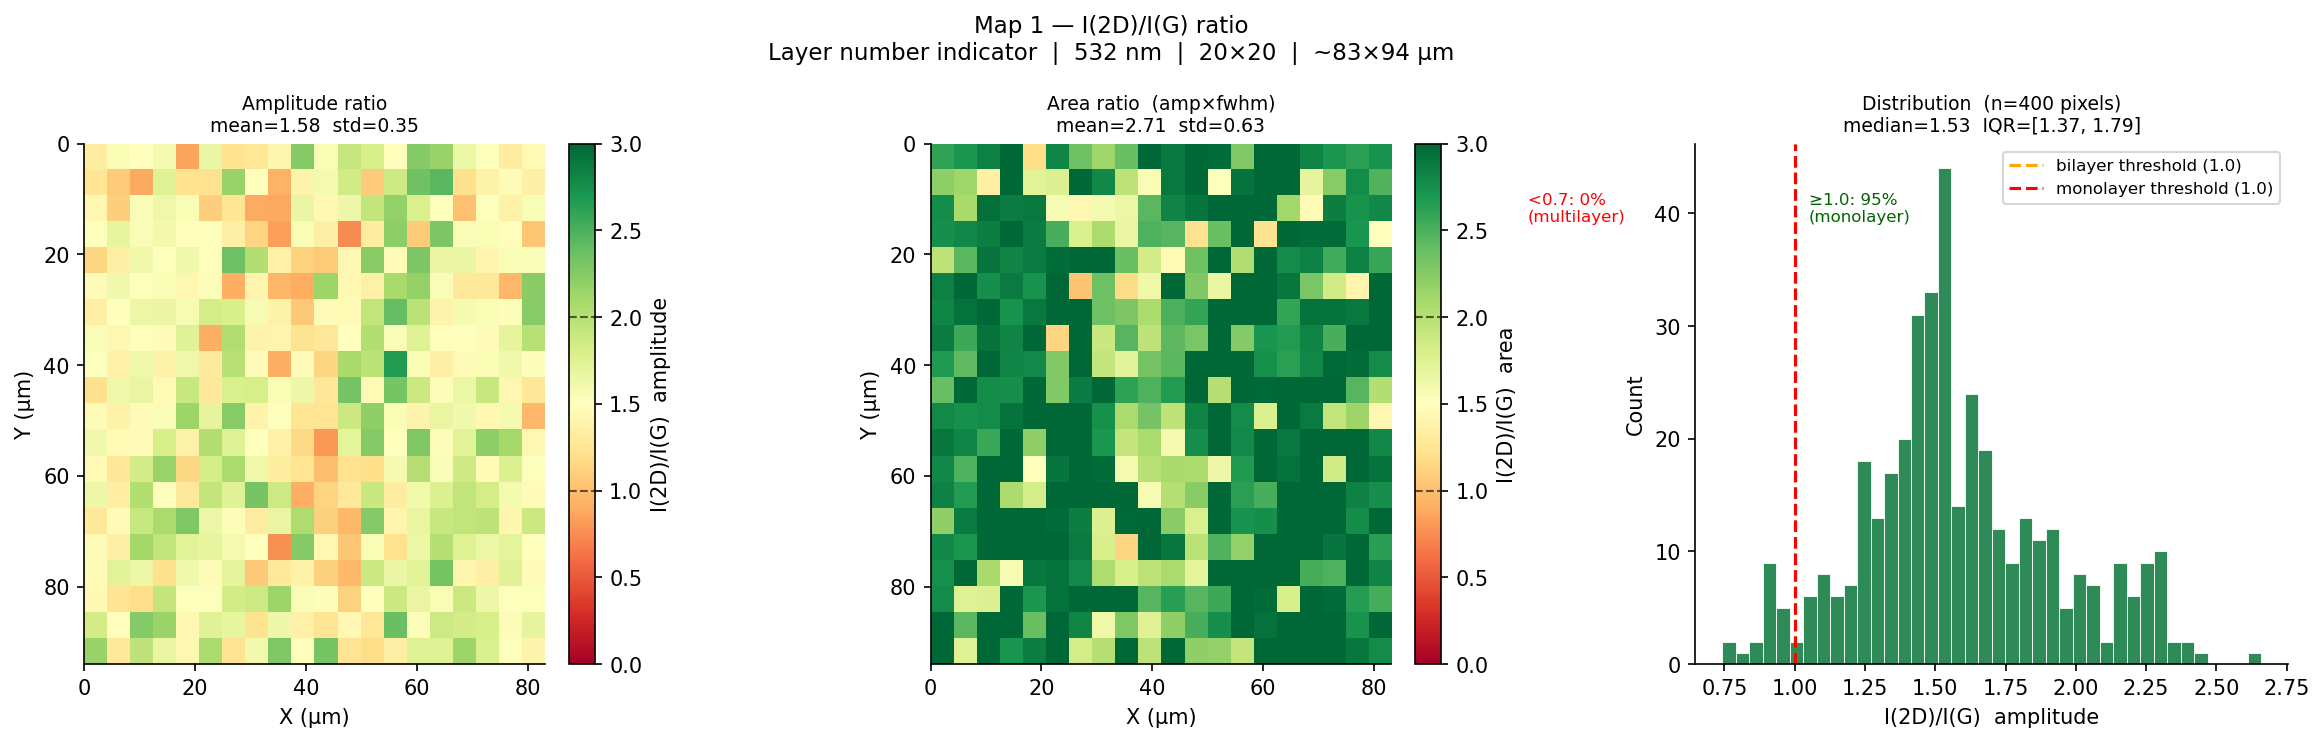

Saved: map01_ratio_2DG.png

── I(2D)/I(G) summary ────────────────────────────────────────────────
                               Amplitude         Area
  --------------------------------------------------
  mean                             1.581        2.710
  std                              0.347        0.629
  median                           1.534        2.797
  min                              0.742        1.037
  max                              2.660        4.301

  Layer fractions (amplitude ratio, threshold=1.0):
  Monolayer  (≥1.0)   : 381/400  (95%)
  Bilayer    (0.7–1.0) :  19/400  (5%)
  Multilayer (<0.7)  :   0/400  (0%)
  ✓ Saved 6 variable(s) → map_results.npz
    ['map_ratio_2dg_amp_mean', 'map_ratio_2dg_amp_std', 'map_ratio_2dg_amp_median', 'map_n_monolayer', 'map_n_bilayer', 'map_n_multilayer']


In [53]:
# ── Cell 4: Map 1 — I(2D)/I(G) ratio ─────────────────────────────────────────
#
# WHY THIS MAP:
# I(2D)/I(G) is the primary Raman indicator of graphene layer number.
# The 2D band intensity relative to G tells you how many graphene layers
# are present at each pixel:
#
#   ratio > 2.0  → monolayer   (strong 2D, single sharp Lorentzian)
#   ratio ~ 1.0  → bilayer     (weaker 2D, broader lineshape)
#   ratio < 0.5  → multilayer  (2D increasingly suppressed)
#
# WHY IT MATTERS FOR YOUR SAMPLE:
# Your CVD graphene was transferred onto SiO₂. The transfer process
# can leave folds, wrinkles, and multilayer patches. This map directly
# shows where the graphene is monolayer vs thicker regions spatially —
# which is the most fundamental characterisation question for a
# transferred graphene film.
#
# WHAT TO LOOK FOR:
#   - Uniform green (ratio > 1.5) → good quality, predominantly monolayer
#   - Yellow patches → bilayer or strained regions
#   - Red/orange spots → multilayer folds, wrinkles, or contamination
#   - Spatial clusters vs random scatter:
#       clusters → real structural features (folds, grain boundaries)
#       scatter  → local doping/strain variation
#   - Correlation with 2D FWHM map (Cell 5) — they should agree:
#       high ratio + narrow FWHM = unambiguous monolayer
#       low ratio + broad FWHM  = unambiguous bilayer/multilayer
#
# NOTE ON CONVENTIONS:
# We show both amplitude ratio and area ratio side by side.
# Area ratio = (amp_2D × fwhm_2D) / (amp_G × fwhm_G) — more rigorous
# when 2D and G have different FWHMs (which they do: ~30 vs ~20 cm⁻¹).
# For your sample the two will differ by ~fwhm_2D/fwhm_G ≈ 1.5×.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Map 1 — I(2D)/I(G) ratio\n"
    "Layer number indicator  |  532 nm  |  20×20  |  ~83×94 µm",
    fontsize=11
)

# ── Reshape to 2D maps ────────────────────────────────────────────────────────
map2d_ratio_amp  = rh.to_map(map_ratio_2dg_amp)
map2d_ratio_area = rh.to_map(map_ratio_2dg_area)

# ── Colour scale ──────────────────────────────────────────────────────────────
# Fixed 0→3 range so both panels share the same scale for direct comparison.
# RdYlGn: red=low ratio (multilayer), green=high ratio (monolayer)
VMIN, VMAX = 0.0, 3.0
CMAP       = "RdYlGn"

# ── Panel 1: Amplitude ratio ──────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#bbbbbb")   # grey for NaN pixels
im = ax.imshow(rh.masked(map2d_ratio_amp),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap=CMAP, vmin=VMIN, vmax=VMAX)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("I(2D)/I(G)  amplitude")
cb.ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.6)   # bilayer threshold
cb.ax.axhline(2.0, color="black", lw=1, ls="--", alpha=0.6)   # monolayer threshold
ax.set_title(f"Amplitude ratio\n"
             f"mean={map_ratio_2dg_amp[~np.isnan(map_ratio_2dg_amp)].mean():.2f}  "
             f"std={map_ratio_2dg_amp[~np.isnan(map_ratio_2dg_amp)].std():.2f}",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 2: Area ratio ───────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor("#bbbbbb")
im2 = ax.imshow(rh.masked(map2d_ratio_area),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap=CMAP, vmin=VMIN, vmax=VMAX)
cb2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("I(2D)/I(G)  area")
cb2.ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.6)
cb2.ax.axhline(2.0, color="black", lw=1, ls="--", alpha=0.6)
ax.set_title(f"Area ratio  (amp×fwhm)\n"
             f"mean={map_ratio_2dg_area[~np.isnan(map_ratio_2dg_area)].mean():.2f}  "
             f"std={map_ratio_2dg_area[~np.isnan(map_ratio_2dg_area)].std():.2f}",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 3: Histogram of amplitude ratio ─────────────────────────────────────
# Shows the full distribution — tells you what fraction of the map
# falls in each layer regime at a glance.
ax = axes[2]
r_valid = map_ratio_2dg_amp[~np.isnan(map_ratio_2dg_amp)]
ax.hist(r_valid, bins=40, color="seagreen", edgecolor="white",
        lw=0.4, density=False)

# Threshold lines
ax.axvline(1.0, color="orange", lw=1.5, ls="--",
           label=f"bilayer threshold (1.0)")
ax.axvline(MONO_RATIO, color="red",    lw=1.5, ls="--",
           label=f"monolayer threshold ({MONO_RATIO})")

# Percentage annotations
n_mono  = np.sum(r_valid >= MONO_RATIO)
n_bi    = np.sum((r_valid >= 0.7) & (r_valid < MONO_RATIO))
n_multi = np.sum(r_valid < 0.7)
ymax    = ax.get_ylim()[1]
ax.text(MONO_RATIO + 0.05, ymax * 0.85,
        f"≥{MONO_RATIO}: {100*n_mono/len(r_valid):.0f}%\n(monolayer)",
        fontsize=8, color="darkgreen")
ax.text(0.05, ymax * 0.85,
        f"<0.7: {100*n_multi/len(r_valid):.0f}%\n(multilayer)",
        fontsize=8, color="red")

ax.set_xlabel("I(2D)/I(G)  amplitude")
ax.set_ylabel("Count")
ax.set_title(f"Distribution  (n={len(r_valid)} pixels)\n"
             f"median={np.median(r_valid):.2f}  "
             f"IQR=[{np.percentile(r_valid,25):.2f}, "
             f"{np.percentile(r_valid,75):.2f}]",
             fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("map01_ratio_2DG.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map01_ratio_2DG.png")

# ── Summary statistics ────────────────────────────────────────────────────────
print(f"\n── I(2D)/I(G) summary ────────────────────────────────────────────────")
print(f"  {'':25} {'Amplitude':>12} {'Area':>12}")
print(f"  {'-'*50}")
for label, arr in [("mean",   lambda a: a.mean()),
                   ("std",    lambda a: a.std()),
                   ("median", lambda a: np.median(a)),
                   ("min",    lambda a: a.min()),
                   ("max",    lambda a: a.max())]:
    va = map_ratio_2dg_amp[~np.isnan(map_ratio_2dg_amp)]
    vb = map_ratio_2dg_area[~np.isnan(map_ratio_2dg_area)]
    print(f"  {label:<25} {arr(va):>12.3f} {arr(vb):>12.3f}")

print(f"\n  Layer fractions (amplitude ratio, threshold={MONO_RATIO}):")
print(f"  Monolayer  (≥{MONO_RATIO})   : "
      f"{n_mono:3d}/{len(r_valid)}  ({100*n_mono/len(r_valid):.0f}%)")
print(f"  Bilayer    (0.7–{MONO_RATIO}) : "
      f"{n_bi:3d}/{len(r_valid)}  ({100*n_bi/len(r_valid):.0f}%)")
print(f"  Multilayer (<0.7)  : "
      f"{n_multi:3d}/{len(r_valid)}  ({100*n_multi/len(r_valid):.0f}%)")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_ratio_2dg_amp_mean   = float(r_valid.mean()),
    map_ratio_2dg_amp_std    = float(r_valid.std()),
    map_ratio_2dg_amp_median = float(np.median(r_valid)),
    map_n_monolayer          = int(n_mono),
    map_n_bilayer            = int(n_bi),
    map_n_multilayer         = int(n_multi),
)

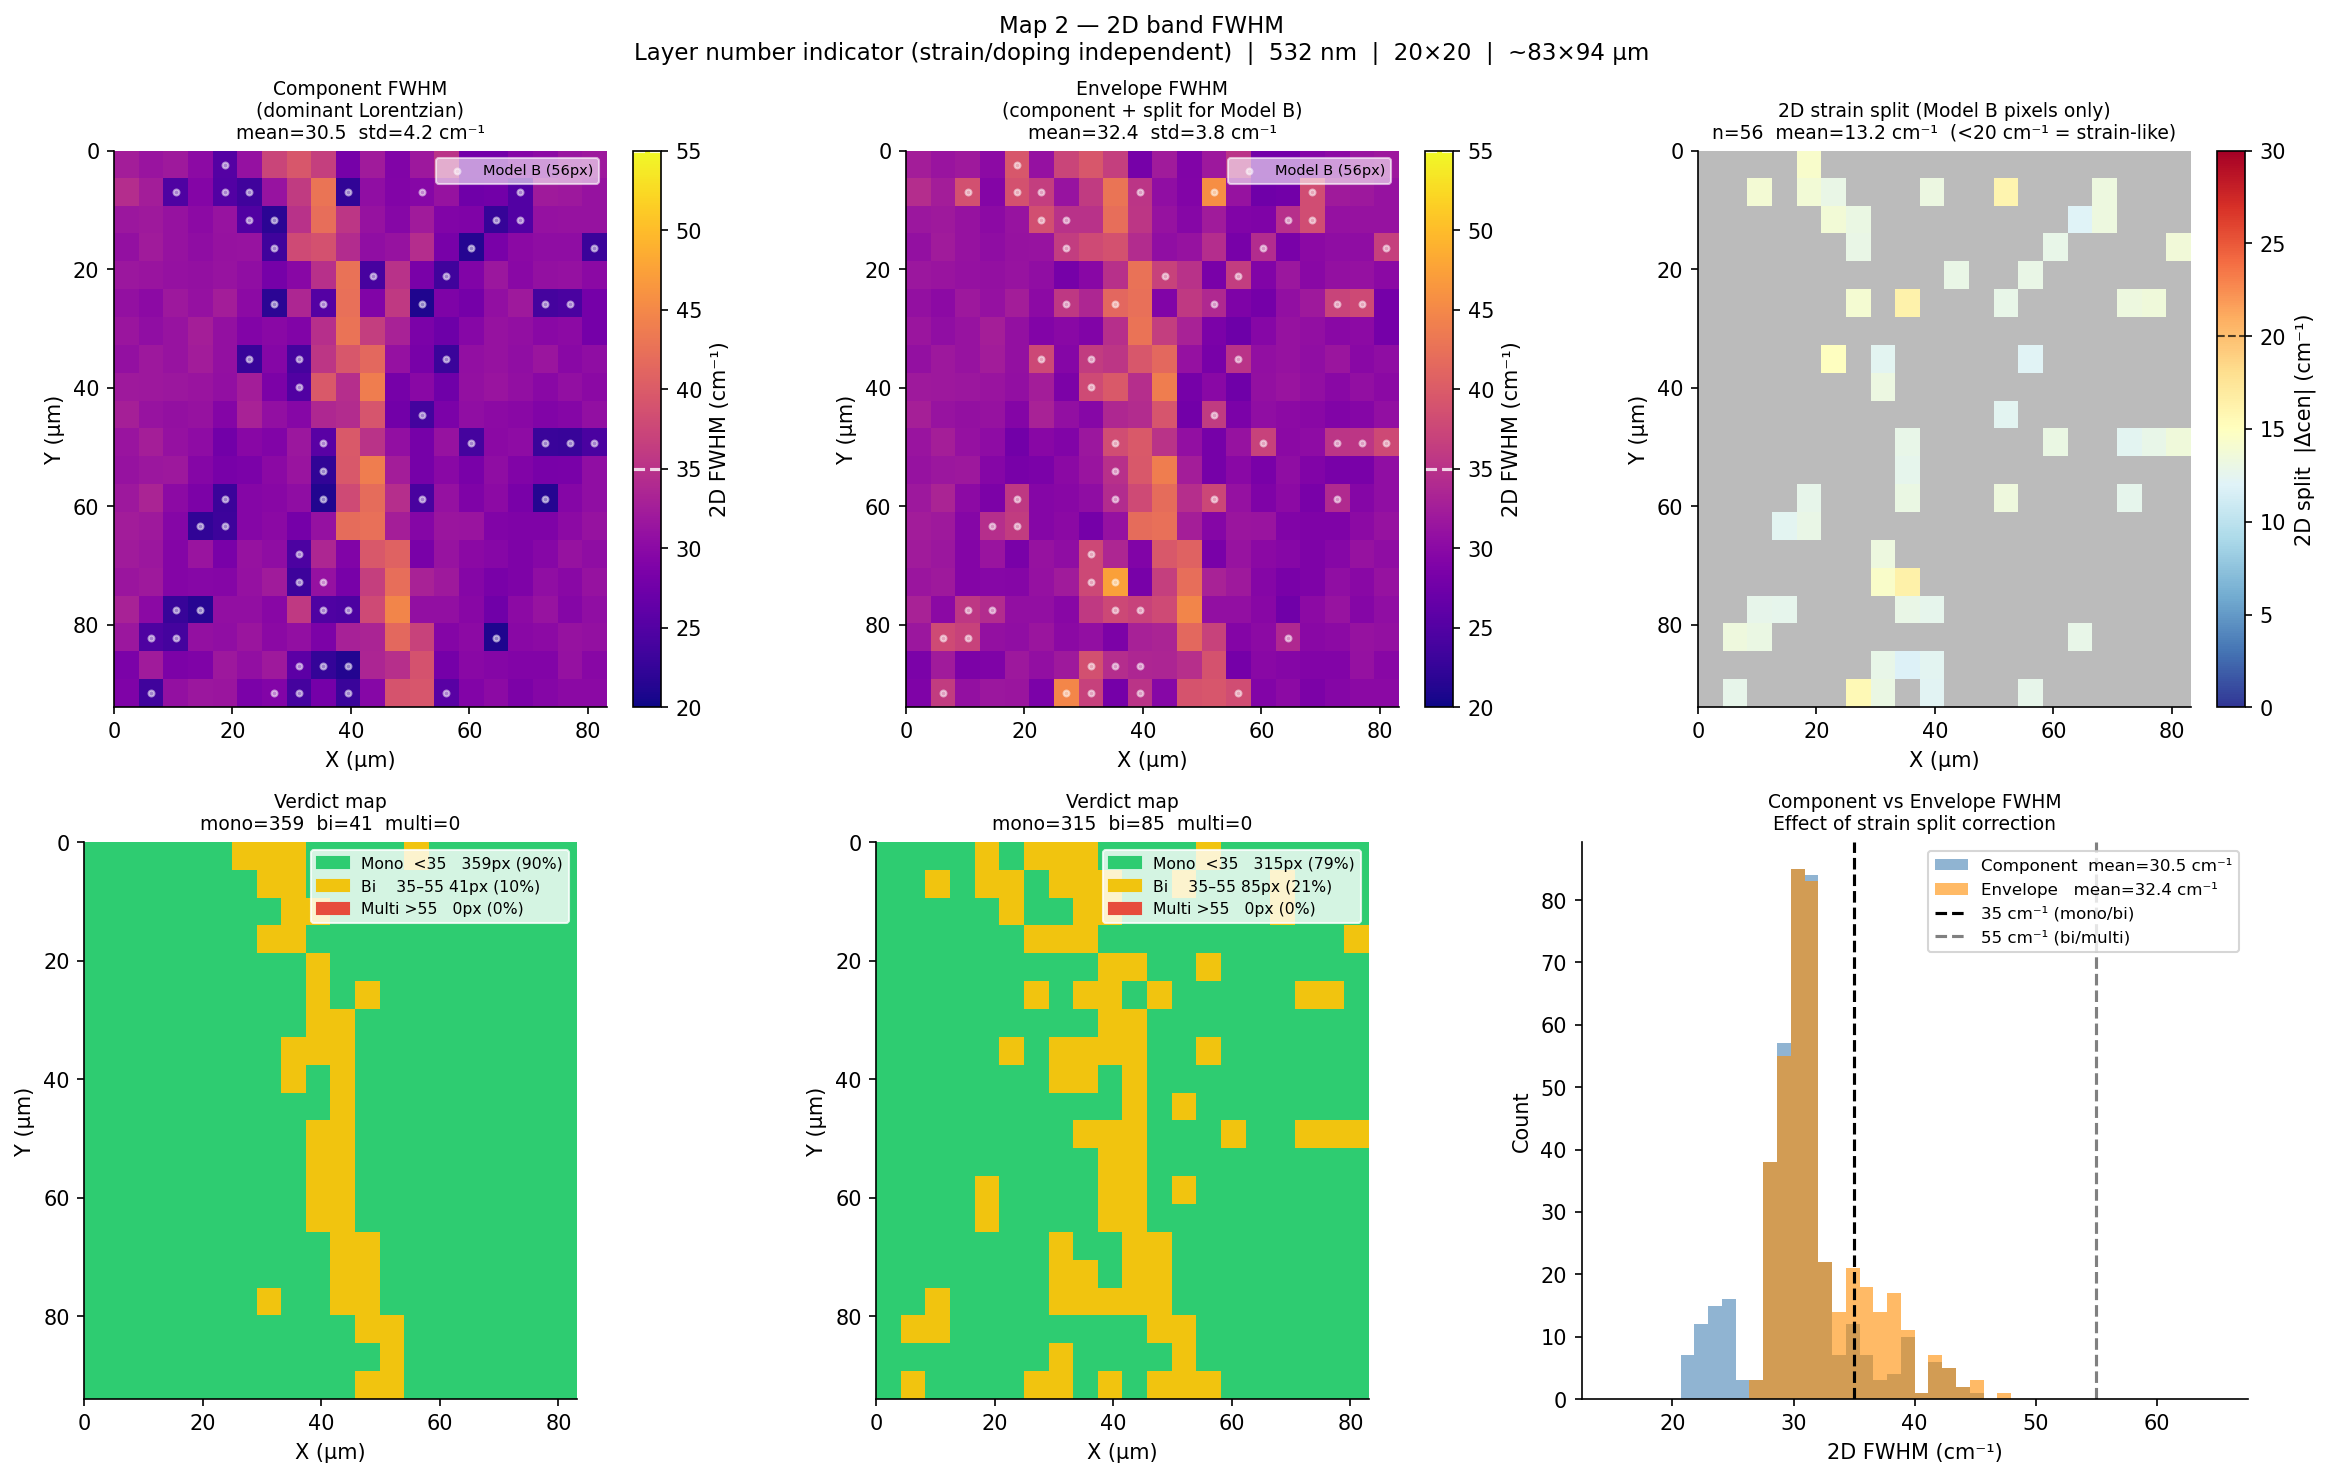

Saved: map02_fwhm_2D.png

── Cross-check: Map 1 (ratio) vs Map 2 (envelope FWHM) ──────────────
  Both say monolayer : 313 px  (78%)
  Both say bilayer   :  17 px  (4%)
  Disagree           :  70 px  (18%)
  → Disagreeing pixels likely strained monolayer
    (strain lowers ratio but envelope FWHM still <35 cm⁻¹)
    OR strain-split pixels where envelope pushed FWHM > 35 cm⁻¹
    but ratio still above threshold
  ✓ Saved 12 variable(s) → map_results.npz
    ['map_fwhm_verdict_comp', 'map_fwhm_verdict_env', 'map_fwhm_comp_n_mono', 'map_fwhm_comp_n_bi', 'map_fwhm_env_n_mono', 'map_fwhm_env_n_bi', 'map_fwhm_comp_mean', 'map_fwhm_env_mean', 'map_td_split_mean', 'map_td_split_n', 'map_ratio_fwhm_agree', 'map_ratio_fwhm_disagree']


In [54]:
# ── Cell 5: Map 2 — 2D band FWHM (envelope-corrected) ────────────────────────
#
# Two FWHM arrays are shown:
#   map_td_fwhm          → dominant component FWHM (what was fitted)
#   map_td_fwhm_envelope → envelope FWHM (component FWHM + split for Model B)
#
# The envelope map is physically correct:
#   Model A pixels: envelope = component FWHM (unchanged)
#   Model B pixels: envelope = component FWHM + split
#     e.g. two components each 25 cm⁻¹ wide separated by 13 cm⁻¹
#     → envelope ≈ 38 cm⁻¹ → correctly classified as borderline/bilayer
#     rather than appearing as a narrow 25 cm⁻¹ monolayer pixel

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Map 2 — 2D band FWHM\n"
    "Layer number indicator (strain/doping independent)  |  "
    "532 nm  |  20×20  |  ~83×94 µm",
    fontsize=11
)

# ── Helper: make verdict array from FWHM ──────────────────────────────────────
def fwhm_to_verdict(fwhm_arr):
    v = np.zeros(N_SPEC, dtype=int)
    v[fwhm_arr < 35]                          = 1   # monolayer
    v[(fwhm_arr >= 35) & (fwhm_arr < 55)]     = 2   # bilayer
    v[fwhm_arr >= 55]                          = 3   # multilayer
    v[np.isnan(fwhm_arr)]                      = 0   # no fit
    return v

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

cmap_v = ListedColormap(["#bbbbbb", "#2ecc71", "#f1c40f", "#e74c3c"])
norm_v = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_v.N)

# ── Row 1: Component FWHM (what was fitted) ───────────────────────────────────
for col, (fwhm_arr, title_suffix) in enumerate([
    (map_td_fwhm,          "Component FWHM\n(dominant Lorentzian)"),
    (map_td_fwhm_envelope, "Envelope FWHM\n(component + split for Model B)"),
]):
    # Spatial map
    ax = axes[0, col]
    ax.set_facecolor("#bbbbbb")
    im = ax.imshow(rh.masked(rh.to_map(fwhm_arr)),
                   origin="upper", extent=EXTENT,
                   aspect="equal", cmap="plasma",
                   vmin=20, vmax=55)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("2D FWHM (cm⁻¹)")
    cb.ax.axhline(35, color="white", lw=1.5, ls="--", alpha=0.8)
    cb.ax.axhline(55, color="white", lw=1.5, ls="--", alpha=0.8)

    # Overlay Model B pixel locations
    model_B_mask = map_td_model == 2
    if np.any(model_B_mask):
        cols_B = (model_B_mask.reshape(NY, NX).nonzero()[1]
                  * STEP_X_UM + STEP_X_UM / 2)
        rows_B = (model_B_mask.reshape(NY, NX).nonzero()[0]
                  * STEP_Y_UM + STEP_Y_UM / 2)
        ax.scatter(cols_B, rows_B, s=8, c="white", alpha=0.5,
                   label=f"Model B ({np.sum(model_B_mask)}px)")
        ax.legend(fontsize=7, loc="upper right",
                  framealpha=0.6, edgecolor="white")

    ax.set_title(f"{title_suffix}\n"
                 f"mean={np.nanmean(fwhm_arr):.1f}  "
                 f"std={np.nanstd(fwhm_arr):.1f} cm⁻¹", fontsize=9)
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")

    # Verdict map
    ax = axes[1, col]
    verdict = fwhm_to_verdict(fwhm_arr)
    n_m = np.sum(verdict == 1)
    n_b = np.sum(verdict == 2)
    n_x = np.sum(verdict == 3)
    ax.set_facecolor("#bbbbbb")
    ax.imshow(rh.masked(rh.to_map(verdict.astype(float))),
              origin="upper", extent=EXTENT,
              aspect="equal", cmap=cmap_v, norm=norm_v,
              interpolation="nearest")
    patches = [
        mpatches.Patch(color="#2ecc71",
                       label=f"Mono  <35   {n_m}px ({100*n_m/N_SPEC:.0f}%)"),
        mpatches.Patch(color="#f1c40f",
                       label=f"Bi    35–55 {n_b}px ({100*n_b/N_SPEC:.0f}%)"),
        mpatches.Patch(color="#e74c3c",
                       label=f"Multi >55   {n_x}px ({100*n_x/N_SPEC:.0f}%)"),
    ]
    ax.legend(handles=patches, fontsize=7.5, loc="upper right",
              framealpha=0.8, edgecolor="white")
    ax.set_title(f"Verdict map\n"
                 f"mono={n_m}  bi={n_b}  multi={n_x}", fontsize=9)
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")

# ── Panel (0,2): Split magnitude map ──────────────────────────────────────────
ax = axes[0, 2]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_td_split)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="RdYlBu_r",
               vmin=0, vmax=30)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("2D split  |Δcen| (cm⁻¹)")
cb.ax.axhline(20, color="black", lw=1, ls="--", alpha=0.7)
n_split = np.sum(~np.isnan(map_td_split))
ax.set_title(f"2D strain split (Model B pixels only)\n"
             f"n={n_split}  "
             f"mean={np.nanmean(map_td_split):.1f} cm⁻¹  "
             f"(<20 cm⁻¹ = strain-like)", fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel (1,2): Histogram comparison ─────────────────────────────────────────
ax = axes[1, 2]
f_comp = map_td_fwhm[~np.isnan(map_td_fwhm)]
f_env  = map_td_fwhm_envelope[~np.isnan(map_td_fwhm_envelope)]
bins   = np.linspace(15, 65, 45)

ax.hist(f_comp, bins=bins, alpha=0.6, color="steelblue",
        label=f"Component  mean={f_comp.mean():.1f} cm⁻¹")
ax.hist(f_env,  bins=bins, alpha=0.6, color="darkorange",
        label=f"Envelope   mean={f_env.mean():.1f} cm⁻¹")
ax.axvline(35, color="black", lw=1.5, ls="--", label="35 cm⁻¹ (mono/bi)")
ax.axvline(55, color="grey",  lw=1.5, ls="--", label="55 cm⁻¹ (bi/multi)")
ax.set_xlabel("2D FWHM (cm⁻¹)")
ax.set_ylabel("Count")
ax.set_title("Component vs Envelope FWHM\nEffect of strain split correction",
             fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("map02_fwhm_2D.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map02_fwhm_2D.png")

# ── Cross-check with Map 1 (ratio) ────────────────────────────────────────────
ratio_says_mono = map_ratio_2dg_amp >= MONO_RATIO
fwhm_says_mono  = map_td_fwhm_envelope < 35
both_valid      = ~np.isnan(map_ratio_2dg_amp) & ~np.isnan(map_td_fwhm_envelope)
agree_mono  = np.sum( ratio_says_mono &  fwhm_says_mono & both_valid)
agree_bi    = np.sum(~ratio_says_mono & ~fwhm_says_mono & both_valid)
disagree    = np.sum((ratio_says_mono ^ fwhm_says_mono) & both_valid)

print(f"\n── Cross-check: Map 1 (ratio) vs Map 2 (envelope FWHM) ──────────────")
print(f"  Both say monolayer : {agree_mono:3d} px  ({100*agree_mono/N_SPEC:.0f}%)")
print(f"  Both say bilayer   : {agree_bi:3d} px  ({100*agree_bi/N_SPEC:.0f}%)")
print(f"  Disagree           : {disagree:3d} px  ({100*disagree/N_SPEC:.0f}%)")
print(f"  → Disagreeing pixels likely strained monolayer")
print(f"    (strain lowers ratio but envelope FWHM still <35 cm⁻¹)")
print(f"    OR strain-split pixels where envelope pushed FWHM > 35 cm⁻¹")
print(f"    but ratio still above threshold")

# ── Save ──────────────────────────────────────────────────────────────────────
verdict_comp = fwhm_to_verdict(map_td_fwhm)
verdict_env  = fwhm_to_verdict(map_td_fwhm_envelope)

save_results(
    map_fwhm_verdict_comp       = verdict_comp,
    map_fwhm_verdict_env        = verdict_env,
    map_fwhm_comp_n_mono        = int(np.sum(verdict_comp == 1)),
    map_fwhm_comp_n_bi          = int(np.sum(verdict_comp == 2)),
    map_fwhm_env_n_mono         = int(np.sum(verdict_env  == 1)),
    map_fwhm_env_n_bi           = int(np.sum(verdict_env  == 2)),
    map_fwhm_comp_mean          = float(np.nanmean(map_td_fwhm)),
    map_fwhm_env_mean           = float(np.nanmean(map_td_fwhm_envelope)),
    map_td_split_mean           = float(np.nanmean(map_td_split)),
    map_td_split_n              = int(np.sum(~np.isnan(map_td_split))),
    map_ratio_fwhm_agree        = int(agree_mono + agree_bi),
    map_ratio_fwhm_disagree     = int(disagree),
)

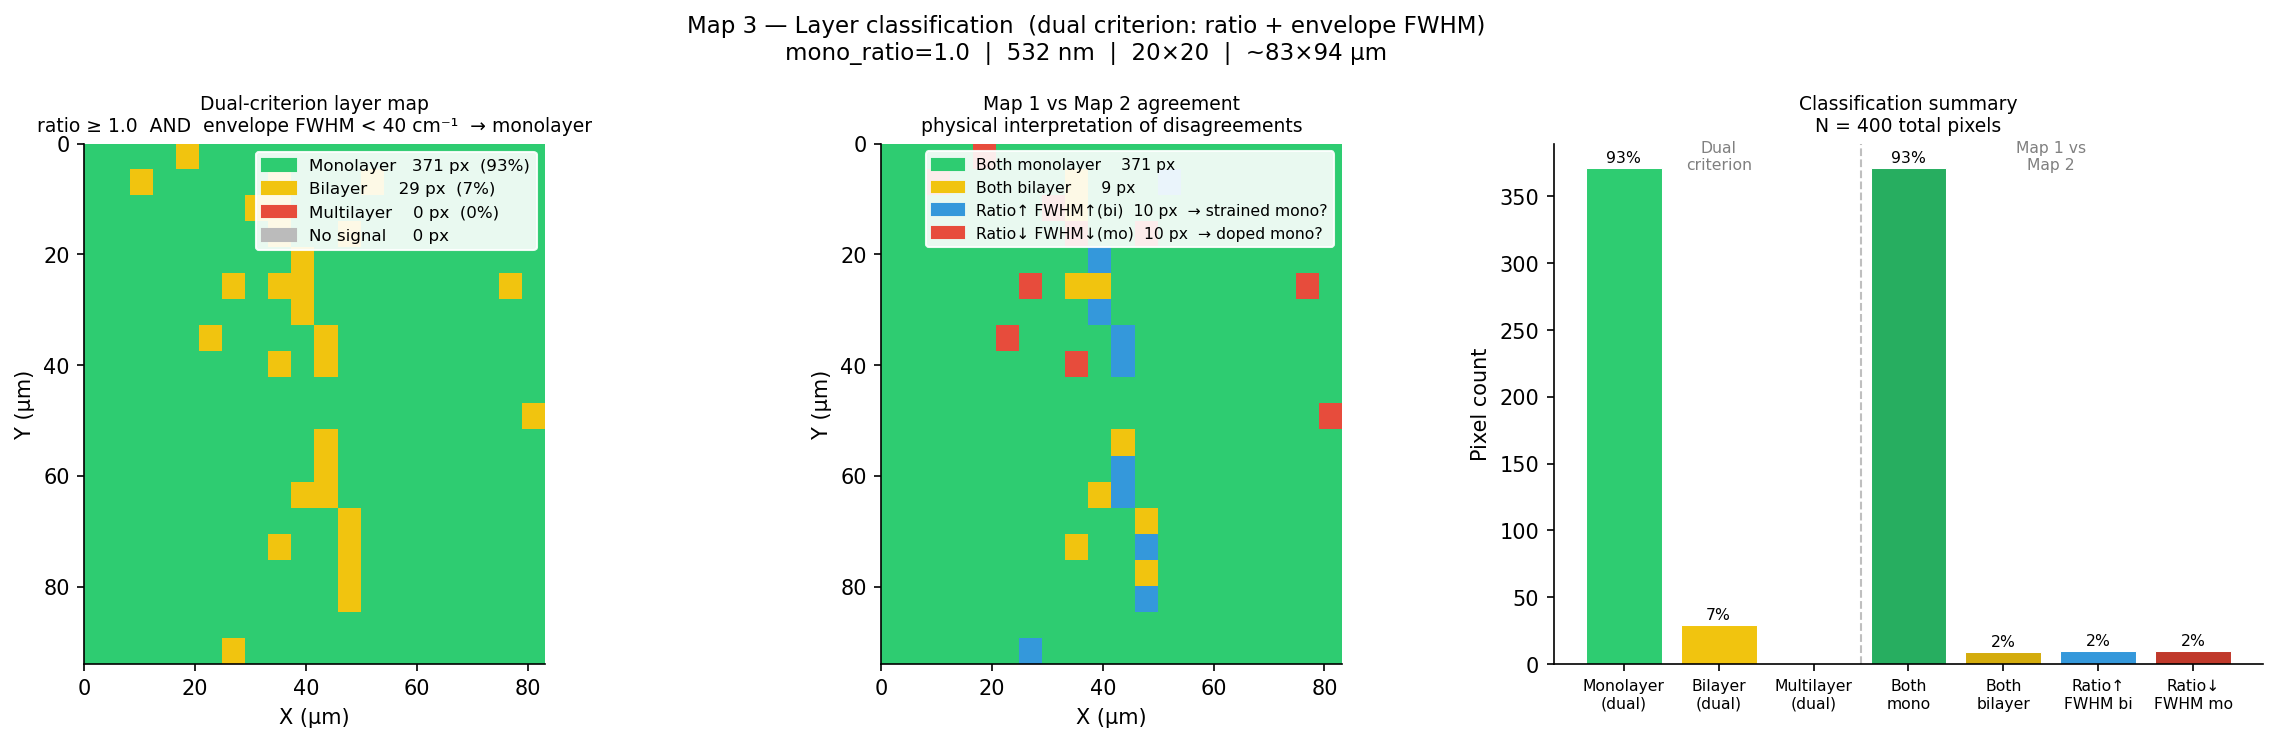

Saved: map03_layer_classification.png

── Layer classification summary ──────────────────────────────────────
  Dual-criterion result:
    Monolayer  : 371 / 400  (93%)
    Bilayer    :  29 / 400  (7%)
    Multilayer :   0 / 400  (0%)
    No signal  :   0 / 400

  Map 1 vs Map 2 agreement:
    Both monolayer              : 371 px  (93%)
    Both bilayer                :   9 px  (2%)
    Ratio↑ but FWHM says bi     :  10 px  → likely strained monolayer
    Ratio↓ but FWHM says mono   :  10 px  → likely doped monolayer
  ✓ Saved 9 variable(s) → map_results.npz
    ['map_layer_n_mono', 'map_layer_n_bi', 'map_layer_n_multi', 'map_layer_n_none', 'map_disagree_map', 'map_disagree_n_agree_m', 'map_disagree_n_agree_b', 'map_disagree_n_ratio_up', 'map_disagree_n_ratio_dn']


In [55]:
# ── Cell 6: Map 3 — Layer classification ──────────────────────────────────────
#
# WHY THIS MAP:
# Maps 1 and 2 each give one criterion for layer number independently.
# Map 3 combines both into a single spatial classification using
# rh.classify_layer — a pixel is called monolayer only if BOTH
# the ratio AND the envelope FWHM agree. This is more robust than
# either criterion alone because:
#
#   Ratio alone can be fooled by:
#     - p-doping from SiO₂ substrate → lowers ratio without adding layers
#     - strain → shifts positions and can reduce ratio
#     - PMMA contamination → modifies local dielectric environment
#
#   FWHM alone can be fooled by:
#     - Strain split → envelope FWHM > 35 cm⁻¹ even for monolayer
#       (we partially corrected this with the envelope approach)
#     - Poor fit convergence in noisy spectra
#
#   Combined criterion → both must independently agree → fewer false calls
#
# CLASSIFICATION RULES (532 nm, mono_ratio = MONO_RATIO = 1.0):
#   Monolayer  : ratio ≥ MONO_RATIO  AND  envelope FWHM < 40 cm⁻¹
#   Bilayer    : ratio ≥ 0.7         AND  envelope FWHM < 55 cm⁻¹
#   Multilayer : ratio < 0.7         OR   envelope FWHM ≥ 55 cm⁻¹
#   No signal  : NaN in either input
#
# WHAT TO LOOK FOR:
#   - Spatial continuity of monolayer region → uniform CVD coverage
#   - Bilayer clusters → graphene folds or overlapping flake edges
#     from the transfer process
#   - Comparison with ratio map (Map 1) and FWHM map (Map 2):
#     pixels that change classification between maps reveal where
#     the two criteria disagree — physically interesting regions
#   - Correlation with defect density map (later) → are bilayer
#     regions also more defective?

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ── Layer classification already computed in Cell 3b ──────────────────────────
# map_layer: 0=no signal, 1=monolayer, 2=bilayer, 3=multilayer
# Uses envelope FWHM + amplitude ratio with mono_ratio = MONO_RATIO

n_none  = int(np.sum(map_layer == 0))
n_mono  = int(np.sum(map_layer == 1))
n_bi    = int(np.sum(map_layer == 2))
n_multi = int(np.sum(map_layer == 3))

# ── Colour map ────────────────────────────────────────────────────────────────
cmap_l = ListedColormap(["#bbbbbb", "#2ecc71", "#f1c40f", "#e74c3c"])
norm_l = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_l.N)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Map 3 — Layer classification  (dual criterion: ratio + envelope FWHM)\n"
    f"mono_ratio={MONO_RATIO}  |  532 nm  |  20×20  |  ~83×94 µm",
    fontsize=11
)

# ── Panel 1: Layer classification map ────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#bbbbbb")
ax.imshow(rh.masked(rh.to_map(map_layer.astype(float))),
          origin="upper", extent=EXTENT,
          aspect="equal", cmap=cmap_l, norm=norm_l,
          interpolation="nearest")
patches = [
    mpatches.Patch(color="#2ecc71",
                   label=f"Monolayer   {n_mono:3d} px  "
                         f"({100*n_mono/N_SPEC:.0f}%)"),
    mpatches.Patch(color="#f1c40f",
                   label=f"Bilayer     {n_bi:3d} px  "
                         f"({100*n_bi/N_SPEC:.0f}%)"),
    mpatches.Patch(color="#e74c3c",
                   label=f"Multilayer  {n_multi:3d} px  "
                         f"({100*n_multi/N_SPEC:.0f}%)"),
    mpatches.Patch(color="#bbbbbb",
                   label=f"No signal   {n_none:3d} px"),
]
ax.legend(handles=patches, fontsize=8, loc="upper right",
          framealpha=0.9, edgecolor="white")
ax.set_title(f"Dual-criterion layer map\n"
             f"ratio ≥ {MONO_RATIO}  AND  envelope FWHM < 40 cm⁻¹  → monolayer",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 2: Where do Map 1 and Map 2 disagree? ───────────────────────────────
# Pixels where ratio says monolayer but FWHM says bilayer (or vice versa)
# are the most physically interesting — likely strained monolayer regions.

ratio_says_mono = map_ratio_2dg_amp >= MONO_RATIO
fwhm_says_mono  = map_td_fwhm_envelope < 40   # matches classify_layer threshold
both_valid      = ~np.isnan(map_ratio_2dg_amp) & ~np.isnan(map_td_fwhm_envelope)

# Build disagreement array
# 0 = no signal, 1 = both mono, 2 = both bi, 3 = ratio mono / fwhm bi,
# 4 = ratio bi / fwhm mono
disagree_map = np.zeros(N_SPEC, dtype=int)
disagree_map[ ratio_says_mono &  fwhm_says_mono & both_valid] = 1  # agree mono
disagree_map[~ratio_says_mono & ~fwhm_says_mono & both_valid] = 2  # agree bi
disagree_map[ ratio_says_mono & ~fwhm_says_mono & both_valid] = 3  # ratio mono, fwhm bi
disagree_map[~ratio_says_mono &  fwhm_says_mono & both_valid] = 4  # ratio bi, fwhm mono

n_agree_m = int(np.sum(disagree_map == 1))
n_agree_b = int(np.sum(disagree_map == 2))
n_dis_rf  = int(np.sum(disagree_map == 3))
n_dis_fr  = int(np.sum(disagree_map == 4))

cmap_d = ListedColormap(["#bbbbbb", "#2ecc71", "#f1c40f",
                          "#3498db", "#e74c3c"])
norm_d = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_d.N)

ax = axes[1]
ax.set_facecolor("#bbbbbb")
ax.imshow(rh.masked(rh.to_map(disagree_map.astype(float))),
          origin="upper", extent=EXTENT,
          aspect="equal", cmap=cmap_d, norm=norm_d,
          interpolation="nearest")
patches_d = [
    mpatches.Patch(color="#2ecc71",
                   label=f"Both monolayer    {n_agree_m} px"),
    mpatches.Patch(color="#f1c40f",
                   label=f"Both bilayer      {n_agree_b} px"),
    mpatches.Patch(color="#3498db",
                   label=f"Ratio↑ FWHM↑(bi)  {n_dis_rf} px  "
                         f"→ strained mono?"),
    mpatches.Patch(color="#e74c3c",
                   label=f"Ratio↓ FWHM↓(mo)  {n_dis_fr} px  "
                         f"→ doped mono?"),
]
ax.legend(handles=patches_d, fontsize=7.5, loc="upper right",
          framealpha=0.9, edgecolor="white")
ax.set_title("Map 1 vs Map 2 agreement\nphysical interpretation of disagreements",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 3: Pixel count breakdown ────────────────────────────────────────────
ax = axes[2]

categories  = ["Monolayer\n(dual)", "Bilayer\n(dual)",
               "Multilayer\n(dual)", "Both\nmono",
               "Both\nbilayer", "Ratio↑\nFWHM bi", "Ratio↓\nFWHM mo"]
counts      = [n_mono, n_bi, n_multi,
               n_agree_m, n_agree_b, n_dis_rf, n_dis_fr]
colors_bar  = ["#2ecc71", "#f1c40f", "#e74c3c",
               "#27ae60", "#d4ac0d", "#3498db", "#c0392b"]
x_pos       = np.arange(len(categories))

bars = ax.bar(x_pos, counts, color=colors_bar,
              edgecolor="white", lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=7.5)
ax.set_ylabel("Pixel count")
ax.set_title(f"Classification summary\n"
             f"N = {N_SPEC} total pixels", fontsize=9)

# Percentage labels on bars
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f"{100*count/N_SPEC:.0f}%",
                ha="center", va="bottom", fontsize=7.5)

# Divider between dual-criterion and agreement categories
ax.axvline(2.5, color="grey", lw=1, ls="--", alpha=0.5)
ax.text(1.0, ax.get_ylim()[1]*0.95, "Dual\ncriterion",
        ha="center", fontsize=7.5, color="grey")
ax.text(4.5, ax.get_ylim()[1]*0.95, "Map 1 vs\nMap 2",
        ha="center", fontsize=7.5, color="grey")

plt.tight_layout()
plt.savefig("map03_layer_classification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map03_layer_classification.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n── Layer classification summary ──────────────────────────────────────")
print(f"  Dual-criterion result:")
print(f"    Monolayer  : {n_mono:3d} / {N_SPEC}  ({100*n_mono/N_SPEC:.0f}%)")
print(f"    Bilayer    : {n_bi:3d} / {N_SPEC}  ({100*n_bi/N_SPEC:.0f}%)")
print(f"    Multilayer : {n_multi:3d} / {N_SPEC}  ({100*n_multi/N_SPEC:.0f}%)")
print(f"    No signal  : {n_none:3d} / {N_SPEC}")
print(f"\n  Map 1 vs Map 2 agreement:")
print(f"    Both monolayer              : {n_agree_m:3d} px  "
      f"({100*n_agree_m/N_SPEC:.0f}%)")
print(f"    Both bilayer                : {n_agree_b:3d} px  "
      f"({100*n_agree_b/N_SPEC:.0f}%)")
print(f"    Ratio↑ but FWHM says bi     : {n_dis_rf:3d} px  "
      f"→ likely strained monolayer")
print(f"    Ratio↓ but FWHM says mono   : {n_dis_fr:3d} px  "
      f"→ likely doped monolayer")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_layer_n_mono        = n_mono,
    map_layer_n_bi          = n_bi,
    map_layer_n_multi       = n_multi,
    map_layer_n_none        = n_none,
    map_disagree_map        = disagree_map,
    map_disagree_n_agree_m  = n_agree_m,
    map_disagree_n_agree_b  = n_agree_b,
    map_disagree_n_ratio_up = n_dis_rf,
    map_disagree_n_ratio_dn = n_dis_fr,
)

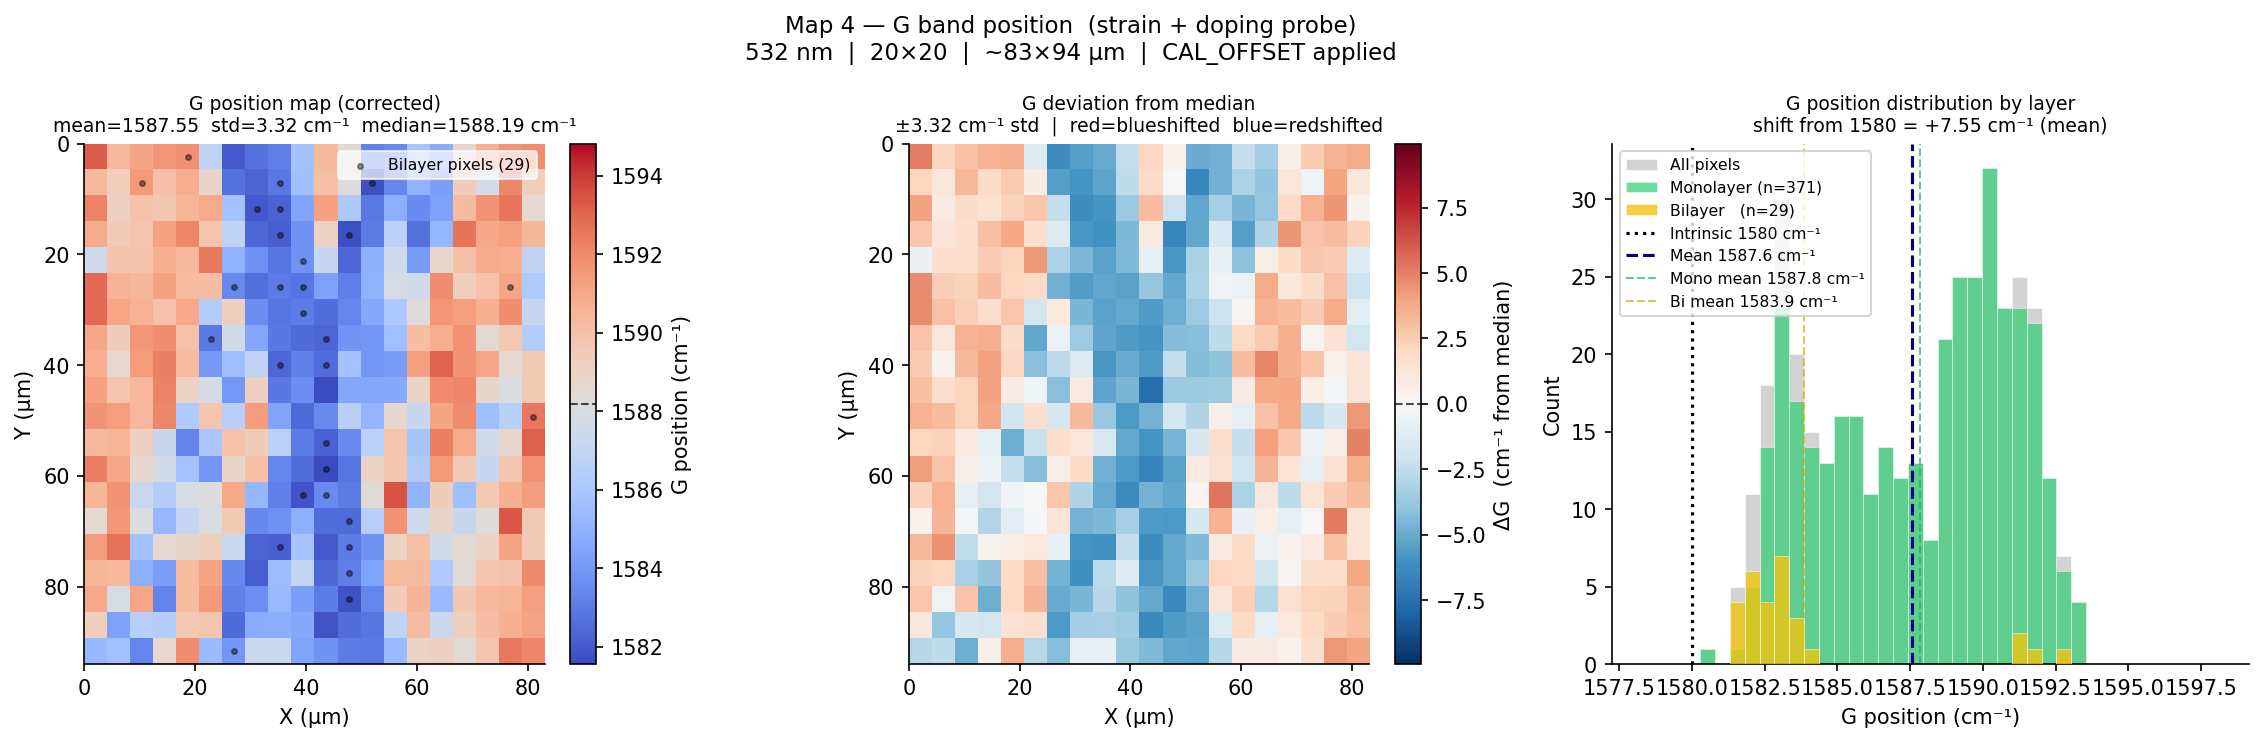

Saved: map04_G_position.png

── G band position summary ───────────────────────────────────────────
  Intrinsic G position : 1580.0 cm⁻¹
  Mean (all pixels)    : 1587.554 cm⁻¹  (shift = +7.554 cm⁻¹)
  Std                  : 3.315 cm⁻¹
  Median               : 1588.190 cm⁻¹
  Range                : 1580.71 – 1593.50 cm⁻¹

  Monolayer mean       : 1587.842 cm⁻¹  (shift = +7.842 cm⁻¹)
  Bilayer mean         : 1583.867 cm⁻¹  (shift = +3.867 cm⁻¹)
  Mono – Bi difference : +3.976 cm⁻¹

  Interpretation:
  +7.6 cm⁻¹ blueshift → consistent with moderate p-doping from SiO₂ substrate
  Spatial std = 3.32 cm⁻¹ → inhomogeneous doping/strain distribution
  ✓ Saved 9 variable(s) → map_results.npz
    ['map_g_cen_mean', 'map_g_cen_std', 'map_g_cen_median', 'map_g_cen_min', 'map_g_cen_max', 'map_g_shift_from_ref', 'map_g_mono_mean', 'map_g_bi_mean', 'map_g_deviation']


In [56]:
# ── Cell 7: Map 4 — G band position ───────────────────────────────────────────
#
# WHY THIS MAP:
# The G band position is sensitive to BOTH strain and doping simultaneously.
# It shifts from its intrinsic position (~1580 cm⁻¹) as follows:
#
#   Compressive strain  → blueshift  (G moves up)
#   Tensile strain      → redshift   (G moves down)
#   p-doping            → blueshift  (G moves up, also narrows)
#   n-doping            → blueshift  (G moves up, but broadens)
#
# Since both strain and doping blueshift G, the G position map alone
# cannot separate the two. That requires the G vs 2D scatter plot (Map 6).
# However the G position map is still valuable because:
#
#   1. Spatial gradients reveal where strain/doping vary across the sample
#   2. Correlation with layer map: bilayer regions often show different G
#      positions due to interlayer interaction changing the phonon frequency
#   3. Comparison with 2D position map (Map 5): if G and 2D shift together
#      with slope ~2.2 → strain dominated; if G shifts but 2D stays ~flat
#      → doping dominated
#
# YOUR SAMPLE:
# Mean G position ~1588 cm⁻¹ — about +8 cm⁻¹ above intrinsic 1580 cm⁻¹.
# This is consistent with moderate p-doping from the SiO₂ substrate,
# which is very common for CVD graphene after wet transfer.
# Any spatial variation in the map reveals where the doping/strain is
# non-uniform — grain boundaries, PMMA residue patches, or substrate
# charge traps can all cause local G position shifts.
#
# WHAT TO LOOK FOR:
#   Uniform colour → homogeneous doping/strain
#   Spatial gradients → systematic strain from substrate or transfer
#   Localised spots → point sources of doping (contamination, defects)
#   Correlation with layer map → bilayer patches often appear as islands
#     of shifted G position

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Map 4 — G band position  (strain + doping probe)\n"
    "532 nm  |  20×20  |  ~83×94 µm  |  CAL_OFFSET applied",
    fontsize=11
)

# ── Compute colour scale centred on median ────────────────────────────────────
# Use median ± 2×std for robust colour range that isn't skewed by outliers
g_valid  = map_g_cen[~np.isnan(map_g_cen)]
g_median = float(np.median(g_valid))
g_std    = float(np.std(g_valid))
g_vmin   = g_median - 2 * g_std
g_vmax   = g_median + 2 * g_std

# ── Panel 1: G position spatial map ───────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_g_cen)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="coolwarm",
               vmin=g_vmin, vmax=g_vmax)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("G position (cm⁻¹)")
cb.ax.axhline(g_median, color="black", lw=1, ls="--",
              alpha=0.7)

# Overlay layer boundaries — show where bilayer pixels are
bi_mask = map_layer == 2
if np.any(bi_mask):
    cols_bi = (bi_mask.reshape(NY, NX).nonzero()[1]
               * STEP_X_UM + STEP_X_UM / 2)
    rows_bi = (bi_mask.reshape(NY, NX).nonzero()[0]
               * STEP_Y_UM + STEP_Y_UM / 2)
    ax.scatter(cols_bi, rows_bi, s=6, c="black",
               alpha=0.4, label=f"Bilayer pixels ({np.sum(bi_mask)})")
    ax.legend(fontsize=7.5, loc="upper right",
              framealpha=0.7, edgecolor="white")

ax.set_title(f"G position map (corrected)\n"
             f"mean={g_valid.mean():.2f}  "
             f"std={g_valid.std():.2f} cm⁻¹  "
             f"median={g_median:.2f} cm⁻¹",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 2: G position — deviation from median ───────────────────────────────
# Plotting deviation rather than absolute position makes spatial
# gradients much more visible — removes the DC offset from doping
# and highlights purely spatial variations
g_deviation = map_g_cen - g_median
dev_std      = float(np.nanstd(g_deviation))

ax = axes[1]
ax.set_facecolor("#bbbbbb")
im2 = ax.imshow(rh.masked(rh.to_map(g_deviation)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="RdBu_r",
                vmin=-3*dev_std, vmax=3*dev_std)
cb2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("ΔG  (cm⁻¹ from median)")
cb2.ax.axhline(0, color="black", lw=1, ls="--", alpha=0.7)
ax.set_title(f"G deviation from median\n"
             f"±{dev_std:.2f} cm⁻¹ std  |  "
             f"red=blueshifted  blue=redshifted",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel 3: G position histogram coloured by layer ───────────────────────────
ax = axes[2]
bins = np.linspace(g_vmin - g_std, g_vmax + g_std, 40)

# Separate monolayer and bilayer distributions
g_mono  = map_g_cen[map_layer == 1]
g_bi    = map_g_cen[map_layer == 2]
g_all   = map_g_cen[~np.isnan(map_g_cen)]

g_mono  = g_mono[~np.isnan(g_mono)]
g_bi    = g_bi[~np.isnan(g_bi)]

ax.hist(g_all,  bins=bins, color="lightgrey",
        edgecolor="white", lw=0.3, label="All pixels",
        zorder=1)
ax.hist(g_mono, bins=bins, color="#2ecc71", alpha=0.7,
        edgecolor="white", lw=0.3, label=f"Monolayer (n={len(g_mono)})",
        zorder=2)
ax.hist(g_bi,   bins=bins, color="#f1c40f", alpha=0.8,
        edgecolor="white", lw=0.3, label=f"Bilayer   (n={len(g_bi)})",
        zorder=3)

ax.axvline(1580,          color="black",  lw=1.5, ls=":",
           label="Intrinsic 1580 cm⁻¹")
ax.axvline(g_valid.mean(), color="navy",  lw=1.5, ls="--",
           label=f"Mean {g_valid.mean():.1f} cm⁻¹")
if len(g_mono) > 0:
    ax.axvline(g_mono.mean(), color="#27ae60", lw=1, ls="--", alpha=0.7,
               label=f"Mono mean {g_mono.mean():.1f} cm⁻¹")
if len(g_bi) > 0:
    ax.axvline(g_bi.mean(), color="#d4ac0d", lw=1, ls="--", alpha=0.7,
               label=f"Bi mean {g_bi.mean():.1f} cm⁻¹")

ax.set_xlabel("G position (cm⁻¹)")
ax.set_ylabel("Count")
ax.set_title(f"G position distribution by layer\n"
             f"shift from 1580 = {g_valid.mean()-1580:+.2f} cm⁻¹ (mean)",
             fontsize=9)
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("map04_G_position.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map04_G_position.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n── G band position summary ───────────────────────────────────────────")
print(f"  Intrinsic G position : 1580.0 cm⁻¹")
print(f"  Mean (all pixels)    : {g_valid.mean():.3f} cm⁻¹  "
      f"(shift = {g_valid.mean()-1580:+.3f} cm⁻¹)")
print(f"  Std                  : {g_valid.std():.3f} cm⁻¹")
print(f"  Median               : {g_median:.3f} cm⁻¹")
print(f"  Range                : {g_valid.min():.2f} – {g_valid.max():.2f} cm⁻¹")
if len(g_mono) > 0 and len(g_bi) > 0:
    print(f"\n  Monolayer mean       : {g_mono.mean():.3f} cm⁻¹  "
          f"(shift = {g_mono.mean()-1580:+.3f} cm⁻¹)")
    print(f"  Bilayer mean         : {g_bi.mean():.3f} cm⁻¹  "
          f"(shift = {g_bi.mean()-1580:+.3f} cm⁻¹)")
    print(f"  Mono – Bi difference : {g_mono.mean()-g_bi.mean():+.3f} cm⁻¹")
print(f"\n  Interpretation:")
print(f"  +{g_valid.mean()-1580:.1f} cm⁻¹ blueshift → consistent with "
      f"moderate p-doping from SiO₂ substrate")
print(f"  Spatial std = {g_valid.std():.2f} cm⁻¹ → "
      f"{'uniform' if g_valid.std() < 3 else 'inhomogeneous'} "
      f"doping/strain distribution")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_g_cen_mean       = float(g_valid.mean()),
    map_g_cen_std        = float(g_valid.std()),
    map_g_cen_median     = float(g_median),
    map_g_cen_min        = float(g_valid.min()),
    map_g_cen_max        = float(g_valid.max()),
    map_g_shift_from_ref = float(g_valid.mean() - 1580.0),
    map_g_mono_mean      = float(g_mono.mean()) if len(g_mono) > 0 else np.nan,
    map_g_bi_mean        = float(g_bi.mean())   if len(g_bi)   > 0 else np.nan,
    map_g_deviation      = g_deviation,
)

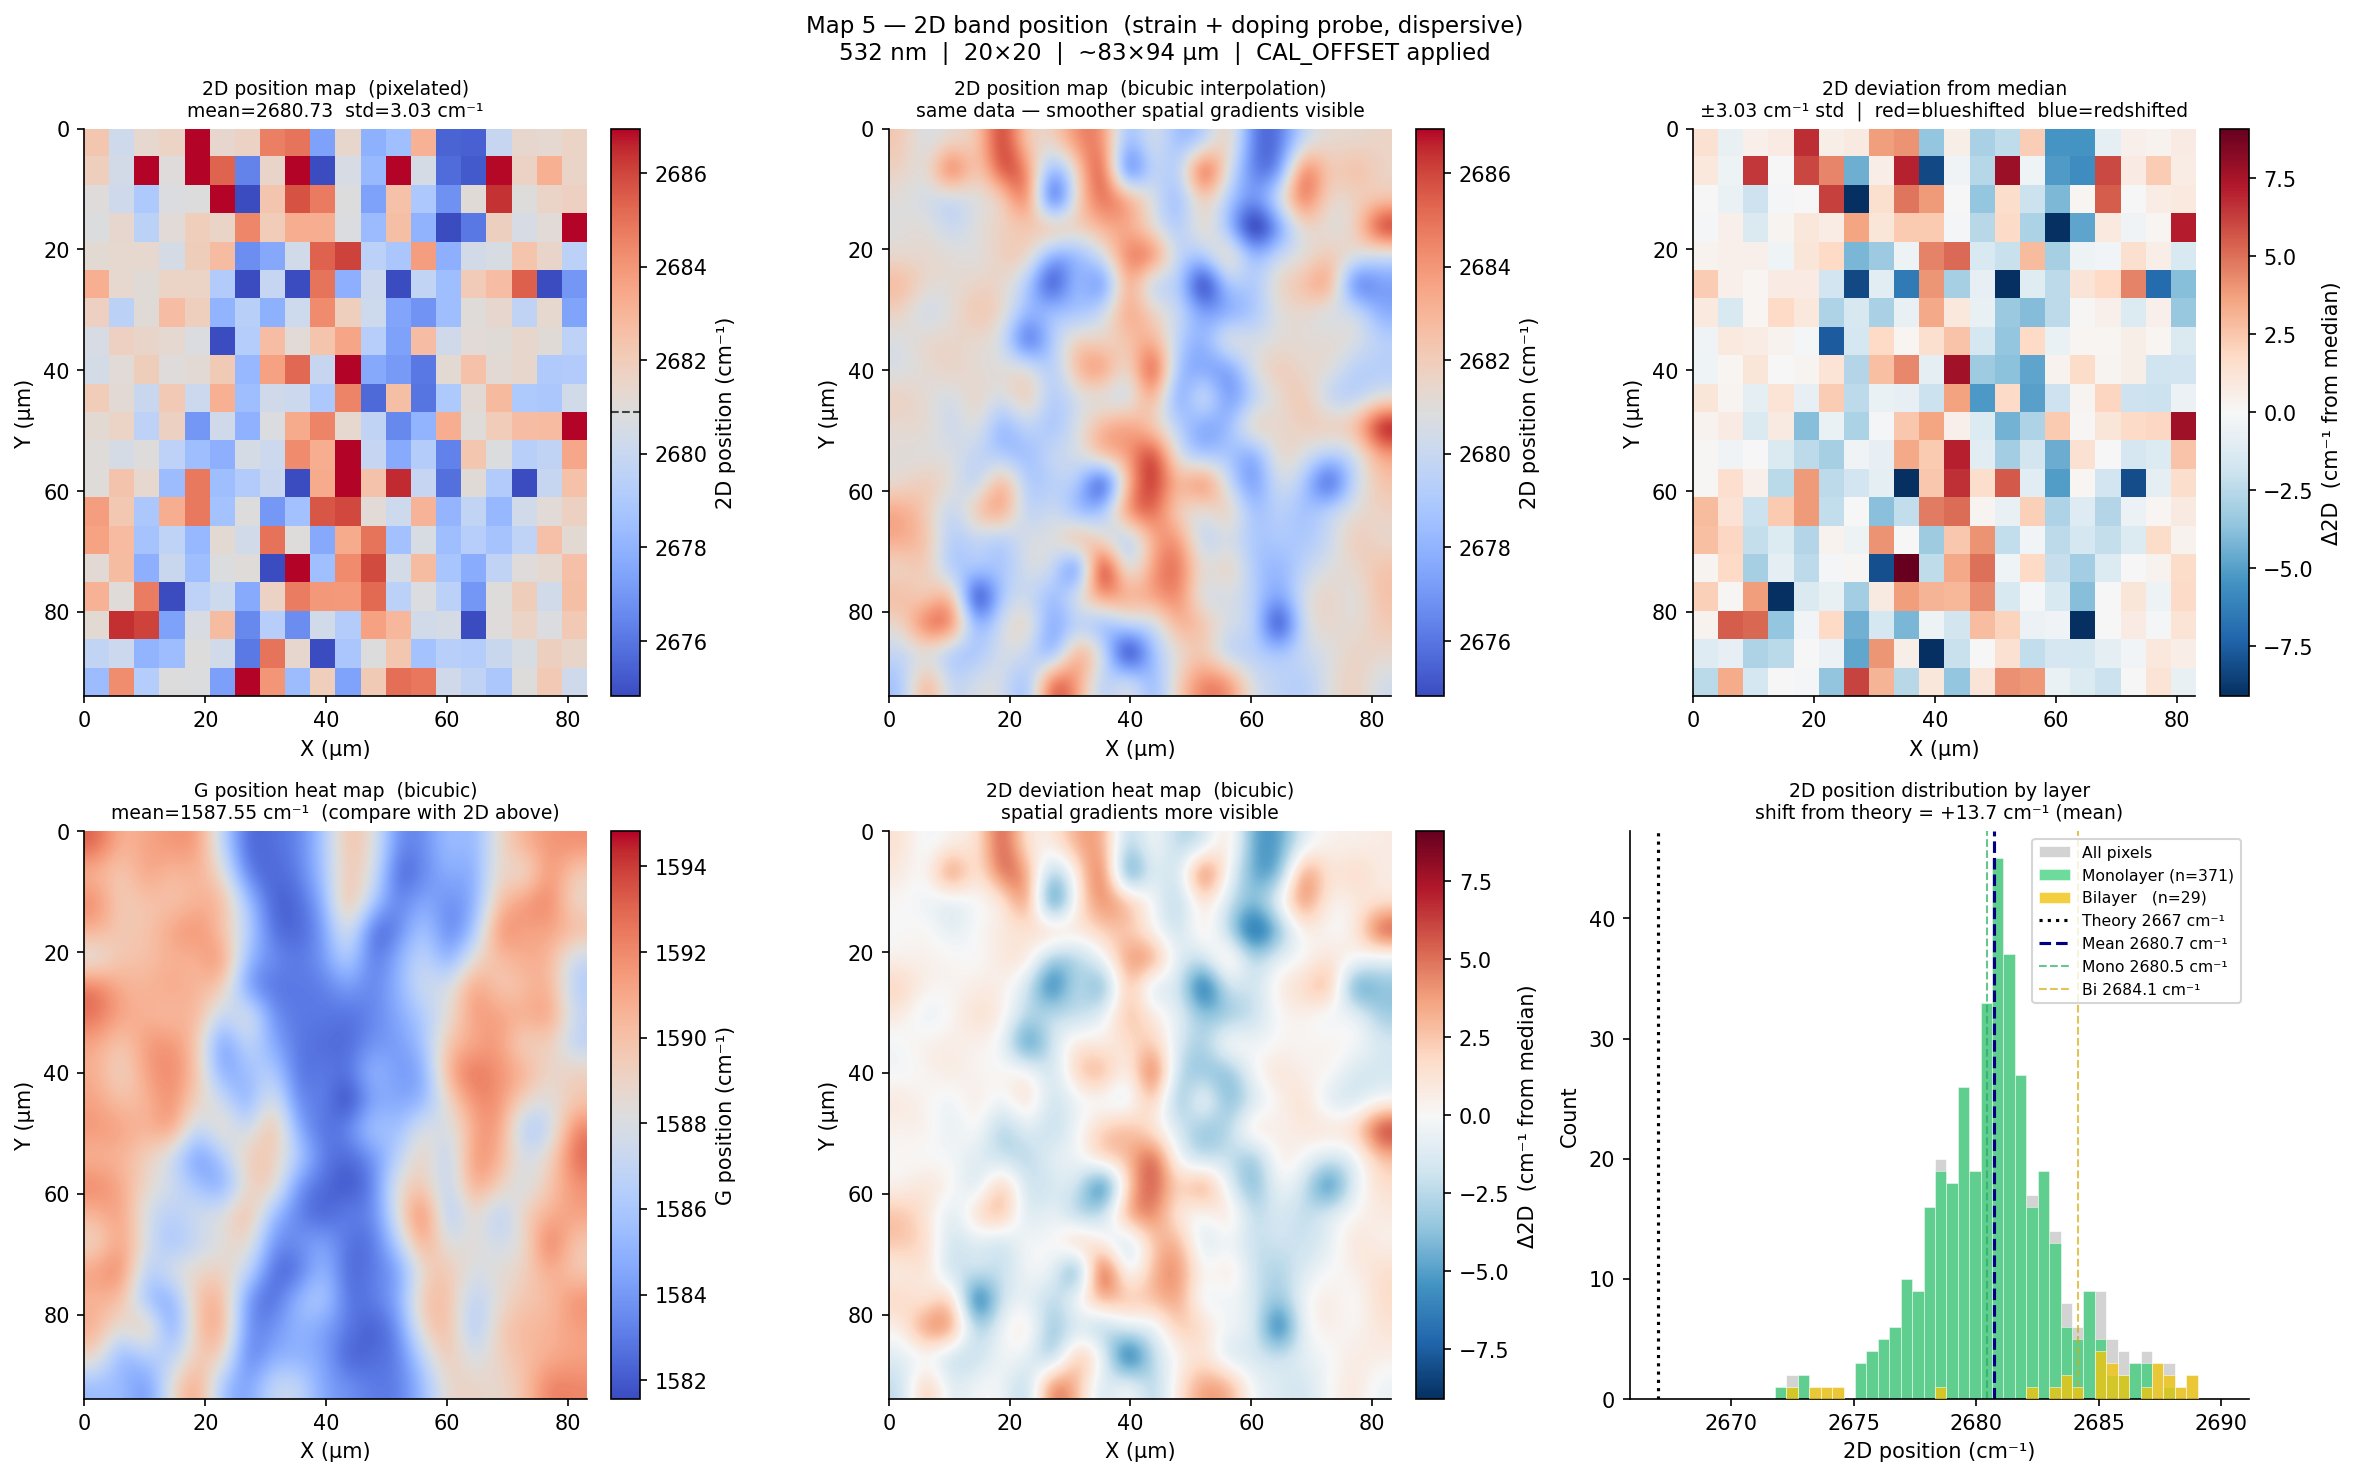

Saved: map05_2D_position.png

── 2D position summary ───────────────────────────────────────────────
  Theoretical (532 nm) : 2667.0 cm⁻¹
  Mean (all pixels)    : 2680.728 cm⁻¹  (shift = +13.728 cm⁻¹)
  Std                  : 3.033 cm⁻¹
  Median               : 2680.884 cm⁻¹
  Monolayer mean       : 2680.461 cm⁻¹
  Bilayer mean         : 2684.149 cm⁻¹
  Mono – Bi difference : -3.688 cm⁻¹

── G vs 2D spatial correlation ───────────────────────────────────────
  Pearson r (G dev vs 2D dev) : 0.121
  Measured slope (Δ2D/ΔG)    : 0.11
  Strain slope reference      : 2.2
  Doping slope reference      : 0.7
  → Slope 0.11 closer to doping (0.7) — spatial variation doping-dominated
  ✓ Saved 9 variable(s) → map_results.npz
    ['map_td_cen_mean', 'map_td_cen_std', 'map_td_cen_median', 'map_td_shift_from_ref', 'map_td_mono_mean', 'map_td_bi_mean', 'map_td_deviation', 'map_corr_G_2D', 'map_slope_2D_G']


In [57]:
# ── Cell 8: Map 5 — 2D band position ──────────────────────────────────────────
#
# WHY THIS MAP:
# The 2D band position is dispersive (~106 cm⁻¹/eV with laser energy)
# and shifts with both strain and doping — but with different sensitivities
# than the G band:
#
#   Biaxial strain  → shifts 2D with slope ~2.2 × G shift
#                     (2D moves ~2.2 cm⁻¹ per 1 cm⁻¹ of G shift)
#   Doping          → shifts G strongly but 2D only weakly
#                     (slope ~0.7 in G vs 2D space)
#
# This different sensitivity is what makes the G vs 2D scatter plot
# (Map 6) so powerful for separating strain from doping.
#
# For 532 nm (2.33 eV):
#   Theoretical 2D position: ~2667 cm⁻¹
#   Typical CVD on SiO₂:     ~2678 cm⁻¹
#   Your sample mean:         ~2685 cm⁻¹ (corrected)
#   Shift from theory: ~+18 cm⁻¹ — consistent with p-doping + slight
#   compressive strain from SiO₂ thermal expansion mismatch
#
# WHAT TO LOOK FOR:
#   Spatial correlation with G position map (Map 4):
#     - If 2D and G shift together with ratio ~2.2 → strain dominates
#     - If G shifts but 2D stays flat → doping dominates
#     - Most real samples show a mixture — the scatter plot quantifies this
#   Layer dependence:
#     - Bilayer 2D is typically broader AND at slightly different position
#       than monolayer due to the four-component structure
#   Comparison with 2D FWHM map (Map 2):
#     - Broader FWHM AND shifted position at same pixels → genuine bilayer
#     - Broader FWHM but normal position → strain split monolayer

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Map 5 — 2D band position  (strain + doping probe, dispersive)\n"
    "532 nm  |  20×20  |  ~83×94 µm  |  CAL_OFFSET applied",
    fontsize=11
)

# ── Colour scale ──────────────────────────────────────────────────────────────
td_valid  = map_td_cen[~np.isnan(map_td_cen)]
td_median = float(np.median(td_valid))
td_std    = float(np.std(td_valid))
td_vmin   = td_median - 2 * td_std
td_vmax   = td_median + 2 * td_std
td_deviation = map_td_cen - td_median

# ── Row 1: Pixelated maps ─────────────────────────────────────────────────────

# Panel (0,0): 2D position — raw pixels
ax = axes[0, 0]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_td_cen)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="coolwarm",
               vmin=td_vmin, vmax=td_vmax,
               interpolation="nearest")
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("2D position (cm⁻¹)")
cb.ax.axhline(td_median, color="black", lw=1, ls="--", alpha=0.7)
ax.set_title(f"2D position map  (pixelated)\n"
             f"mean={td_valid.mean():.2f}  "
             f"std={td_valid.std():.2f} cm⁻¹", fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# Panel (0,1): 2D position — heat map (interpolated)
ax = axes[0, 1]
ax.set_facecolor("#bbbbbb")
im2 = ax.imshow(rh.masked(rh.to_map(map_td_cen)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="coolwarm",
                vmin=td_vmin, vmax=td_vmax,
                interpolation="bicubic")   # ← heat map interpolation
cb2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("2D position (cm⁻¹)")
ax.set_title(f"2D position map  (bicubic interpolation)\n"
             f"same data — smoother spatial gradients visible",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# Panel (0,2): 2D deviation from median
ax = axes[0, 2]
ax.set_facecolor("#bbbbbb")
dev_std_td = float(np.nanstd(td_deviation))
im3 = ax.imshow(rh.masked(rh.to_map(td_deviation)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="RdBu_r",
                vmin=-3*dev_std_td, vmax=3*dev_std_td,
                interpolation="nearest")
cb3 = plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
cb3.set_label("Δ2D  (cm⁻¹ from median)")
ax.set_title(f"2D deviation from median\n"
             f"±{dev_std_td:.2f} cm⁻¹ std  |  "
             f"red=blueshifted  blue=redshifted",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Row 2: Heat maps with physical overlays ───────────────────────────────────

# Panel (1,0): G position heat map
ax = axes[1, 0]
ax.set_facecolor("#bbbbbb")
im4 = ax.imshow(rh.masked(rh.to_map(map_g_cen)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="coolwarm",
                vmin=g_vmin, vmax=g_vmax,
                interpolation="bicubic")
cb4 = plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
cb4.set_label("G position (cm⁻¹)")
ax.set_title(f"G position heat map  (bicubic)\n"
             f"mean={g_valid.mean():.2f} cm⁻¹  "
             f"(compare with 2D above)", fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# Panel (1,1): 2D deviation heat map
ax = axes[1, 1]
ax.set_facecolor("#bbbbbb")
im5 = ax.imshow(rh.masked(rh.to_map(td_deviation)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="RdBu_r",
                vmin=-3*dev_std_td, vmax=3*dev_std_td,
                interpolation="bicubic")
cb5 = plt.colorbar(im5, ax=ax, fraction=0.046, pad=0.04)
cb5.set_label("Δ2D  (cm⁻¹ from median)")
ax.set_title("2D deviation heat map  (bicubic)\n"
             "spatial gradients more visible", fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# Panel (1,2): 2D histogram split by layer
ax = axes[1, 2]
bins   = np.linspace(td_vmin - td_std, td_vmax + td_std, 40)

td_mono = map_td_cen[map_layer == 1]
td_bi   = map_td_cen[map_layer == 2]
td_all  = map_td_cen[~np.isnan(map_td_cen)]

td_mono = td_mono[~np.isnan(td_mono)]
td_bi   = td_bi[~np.isnan(td_bi)]

ax.hist(td_all,  bins=bins, color="lightgrey",
        edgecolor="white", lw=0.3, label="All pixels", zorder=1)
ax.hist(td_mono, bins=bins, color="#2ecc71", alpha=0.7,
        edgecolor="white", lw=0.3,
        label=f"Monolayer (n={len(td_mono)})", zorder=2)
ax.hist(td_bi,   bins=bins, color="#f1c40f", alpha=0.8,
        edgecolor="white", lw=0.3,
        label=f"Bilayer   (n={len(td_bi)})", zorder=3)

ax.axvline(2667,           color="black", lw=1.5, ls=":",
           label="Theory 2667 cm⁻¹")
ax.axvline(td_valid.mean(), color="navy", lw=1.5, ls="--",
           label=f"Mean {td_valid.mean():.1f} cm⁻¹")
if len(td_mono) > 0:
    ax.axvline(td_mono.mean(), color="#27ae60", lw=1, ls="--",
               alpha=0.7, label=f"Mono {td_mono.mean():.1f} cm⁻¹")
if len(td_bi) > 0:
    ax.axvline(td_bi.mean(), color="#d4ac0d", lw=1, ls="--",
               alpha=0.7, label=f"Bi {td_bi.mean():.1f} cm⁻¹")

ax.set_xlabel("2D position (cm⁻¹)")
ax.set_ylabel("Count")
ax.set_title(f"2D position distribution by layer\n"
             f"shift from theory = "
             f"{td_valid.mean()-2667:+.1f} cm⁻¹ (mean)",
             fontsize=9)
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("map05_2D_position.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map05_2D_position.png")

# ── G vs 2D spatial correlation ───────────────────────────────────────────────
# Quick check: do G and 2D shift together spatially?
# Pearson correlation between G deviation and 2D deviation across all pixels
both_valid = ~np.isnan(map_g_cen) & ~np.isnan(map_td_cen)
g_dev_v    = (map_g_cen  - g_median)[both_valid]
td_dev_v   = (map_td_cen - td_median)[both_valid]
corr_G_2D  = float(np.corrcoef(g_dev_v, td_dev_v)[0, 1])

# Measured slope of 2D vs G spatial correlation
slope_2D_G = float(np.polyfit(g_dev_v, td_dev_v, 1)[0])

print(f"\n── 2D position summary ───────────────────────────────────────────────")
print(f"  Theoretical (532 nm) : 2667.0 cm⁻¹")
print(f"  Mean (all pixels)    : {td_valid.mean():.3f} cm⁻¹  "
      f"(shift = {td_valid.mean()-2667:+.3f} cm⁻¹)")
print(f"  Std                  : {td_valid.std():.3f} cm⁻¹")
print(f"  Median               : {td_median:.3f} cm⁻¹")
if len(td_mono) > 0 and len(td_bi) > 0:
    print(f"  Monolayer mean       : {td_mono.mean():.3f} cm⁻¹")
    print(f"  Bilayer mean         : {td_bi.mean():.3f} cm⁻¹")
    print(f"  Mono – Bi difference : {td_mono.mean()-td_bi.mean():+.3f} cm⁻¹")

print(f"\n── G vs 2D spatial correlation ───────────────────────────────────────")
print(f"  Pearson r (G dev vs 2D dev) : {corr_G_2D:.3f}")
print(f"  Measured slope (Δ2D/ΔG)    : {slope_2D_G:.2f}")
print(f"  Strain slope reference      : 2.2")
print(f"  Doping slope reference      : 0.7")
if slope_2D_G > 1.5:
    print(f"  → Slope {slope_2D_G:.2f} closer to strain (2.2) "
          f"— spatial variation strain-dominated")
elif slope_2D_G > 0.9:
    print(f"  → Slope {slope_2D_G:.2f} intermediate "
          f"— mixed strain and doping")
else:
    print(f"  → Slope {slope_2D_G:.2f} closer to doping (0.7) "
          f"— spatial variation doping-dominated")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_td_cen_mean       = float(td_valid.mean()),
    map_td_cen_std        = float(td_valid.std()),
    map_td_cen_median     = float(td_median),
    map_td_shift_from_ref = float(td_valid.mean() - 2667.0),
    map_td_mono_mean      = float(td_mono.mean()) if len(td_mono) > 0 else np.nan,
    map_td_bi_mean        = float(td_bi.mean())   if len(td_bi)   > 0 else np.nan,
    map_td_deviation      = td_deviation,
    map_corr_G_2D         = corr_G_2D,
    map_slope_2D_G        = slope_2D_G,
)

── Strain/doping uncertainties ───────────────────────────────────
  σ_strain mean  : 0.0649 ×10⁻²%
  σ_doping mean  : 0.0014 ×10¹³ cm⁻²
  Strain SNR     : 27.4×  ✓ significant
  Doping SNR     : 41.0×  ✓ significant


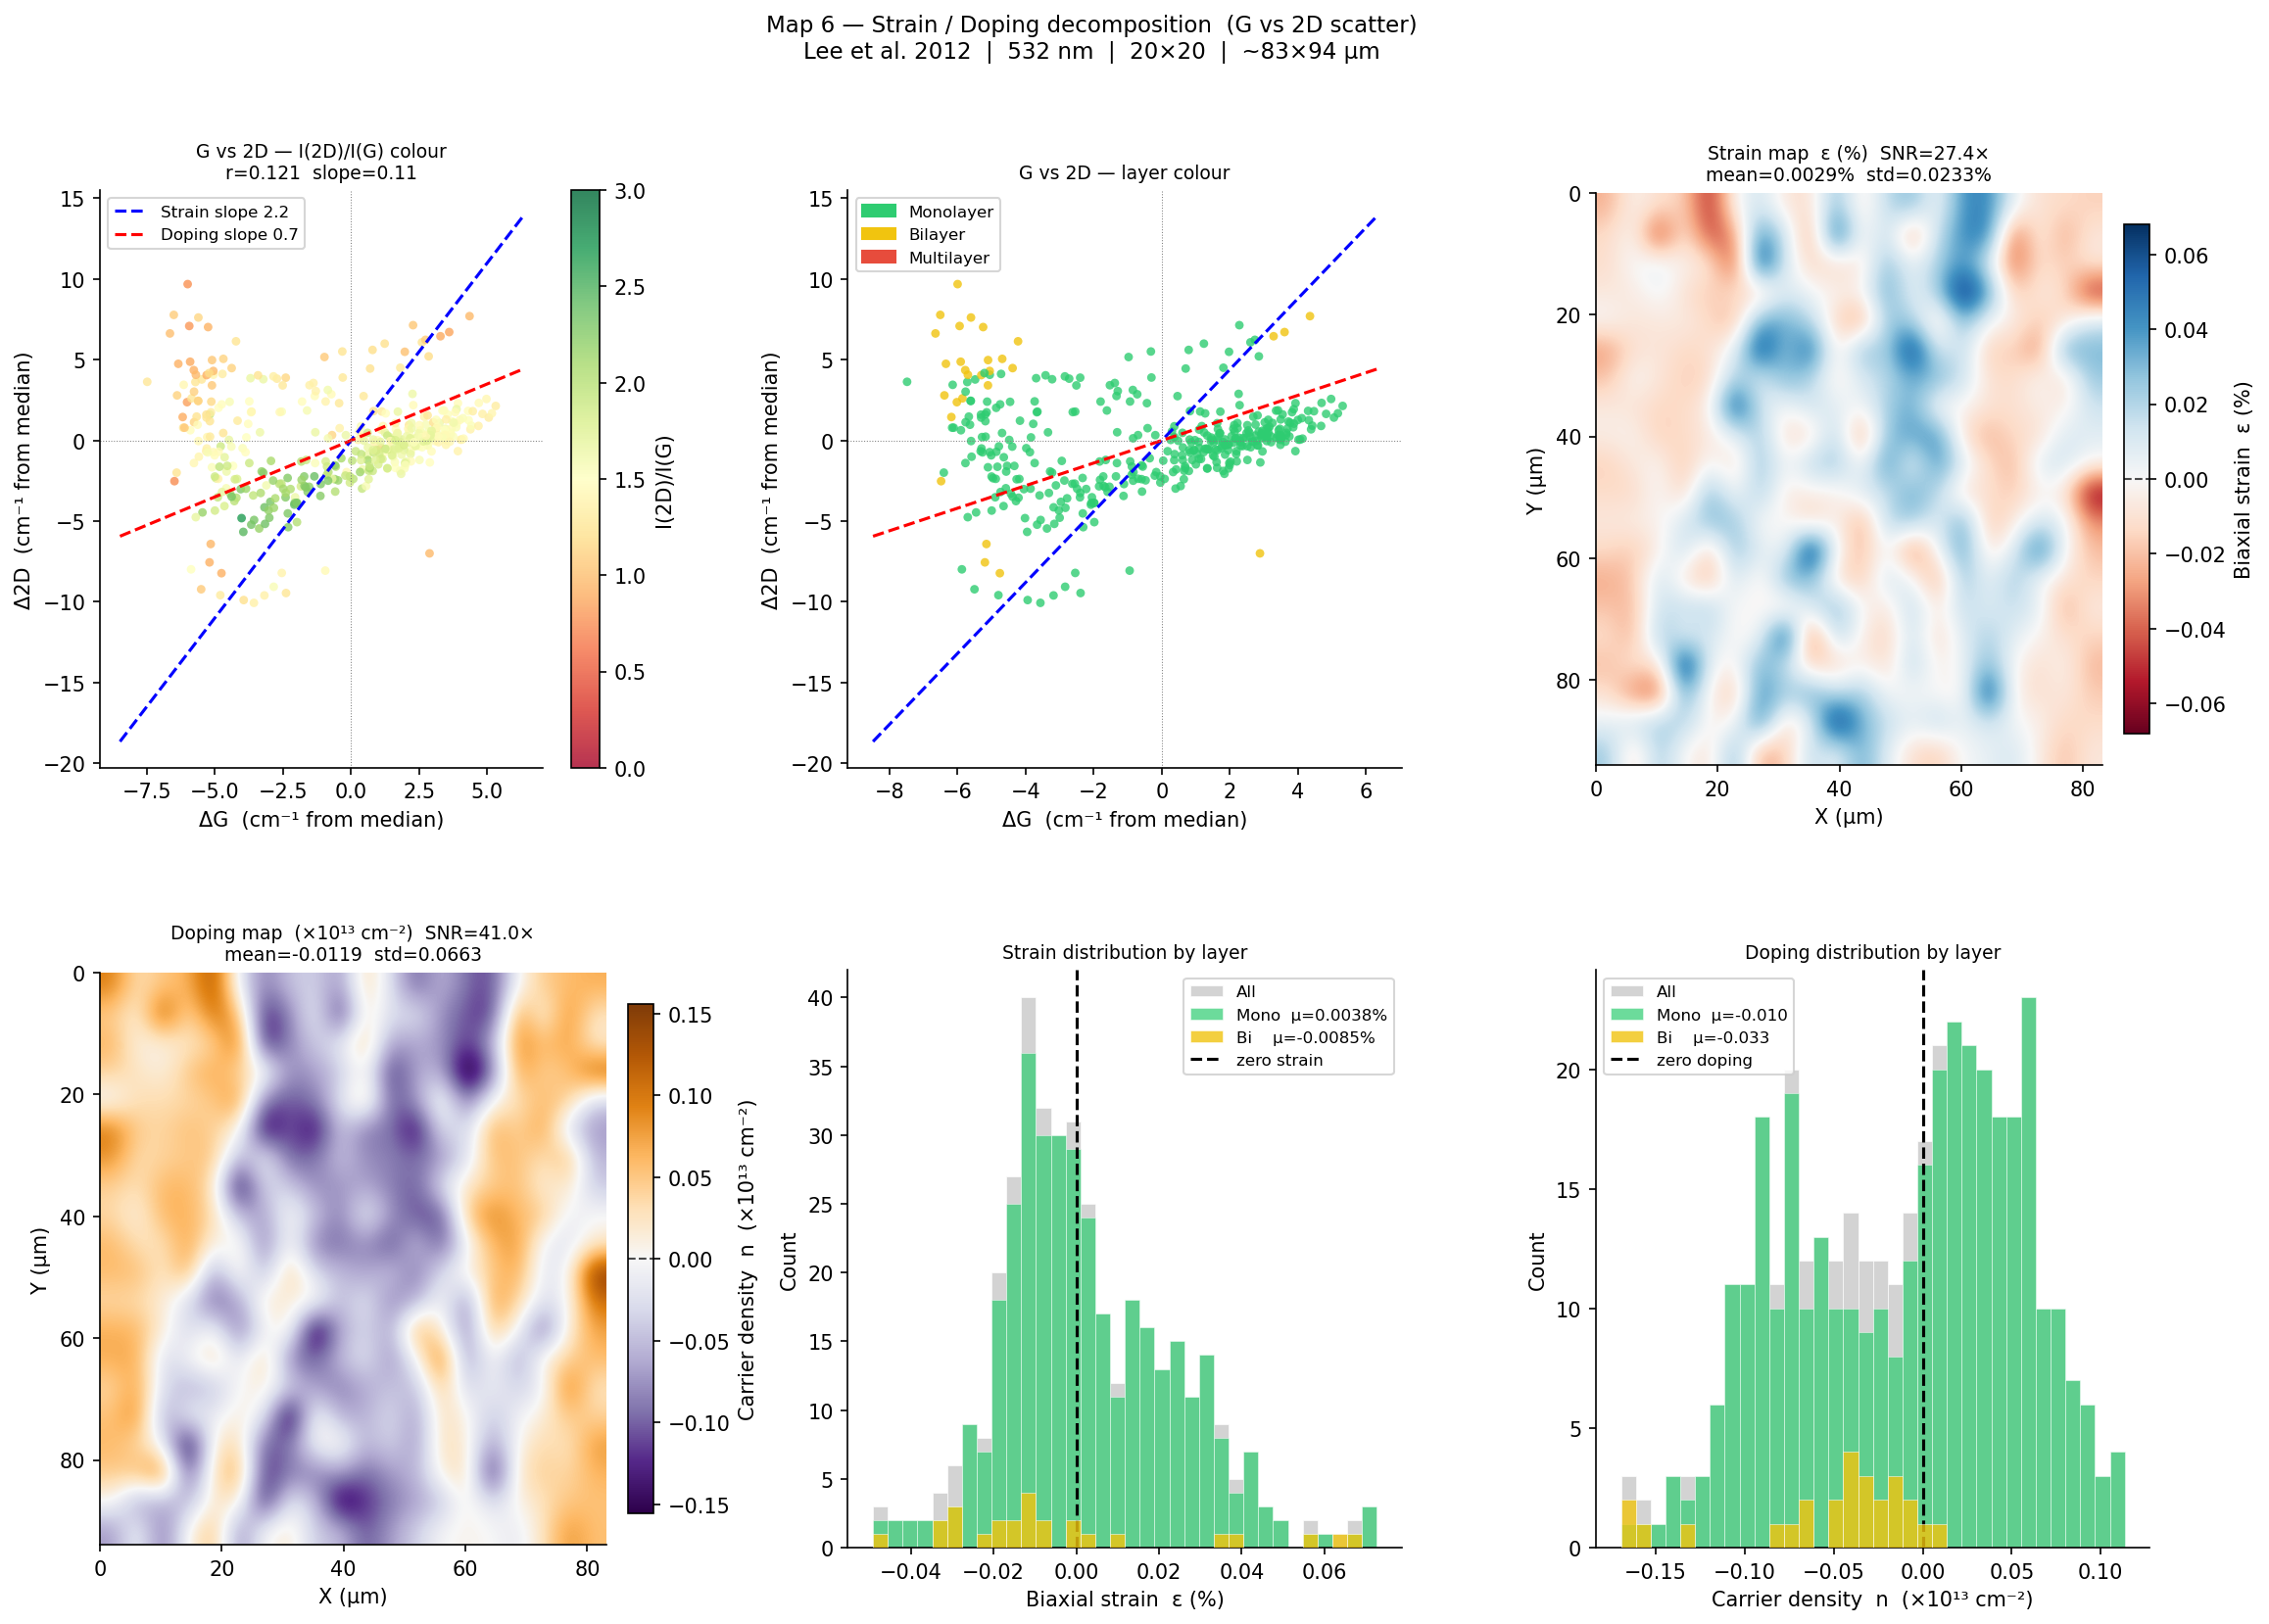

Saved: map06_strain_doping.png

── Strain / doping decomposition summary ─────────────────────────────
  Reference  : G=1588.19 cm⁻¹   2D=2680.88 cm⁻¹  (medians)
  Slope      : 0.11  (doping-like)

  Strain ε (biaxial):
    mean ± std = 0.0029 ± 0.0233 %
    range      = [-0.0636, 0.0774] %
    SNR        = 27.4×

  Doping n (×10¹³ cm⁻²):
    mean ± std = -0.0119 ± 0.0663
    range      = [-0.1910, 0.1557]
    SNR        = 41.0×

  Mono vs Bi:
    Strain: mono=0.0038%  bi=-0.0085%  diff=+0.0124%
    Doping: mono=-0.0103   bi=-0.0326   diff=+0.0223
  ✓ Saved 16 variable(s) → map_results.npz
    ['map_strain_pct', 'map_doping_n13', 'map_proj_strain', 'map_proj_doping', 'map_sigma_strain', 'map_sigma_doping', 'map_strain_mean', 'map_strain_std', 'map_doping_mean', 'map_doping_std', 'map_strain_snr', 'map_doping_snr', 'map_G_ref', 'map_2D_ref', 'map_slope_strain_ref', 'map_slope_doping_ref']


In [63]:
# ── Cell 9: Map 6 — G vs 2D scatter plot (strain/doping decomposition) ────────
#
# WHY THIS MAP:
# This is the most physically informative plot in the entire analysis.
# It separates strain and doping contributions quantitatively by exploiting
# the fact that they shift G and 2D with different slopes:
#
#   Biaxial strain  → moves BOTH G and 2D, slope Δ(2D)/Δ(G) ≈ 2.2
#                     (2D phonon is more sensitive to strain than G)
#   Charge doping   → moves G strongly, 2D weakly, slope ≈ 0.7
#                     (doping mainly affects the Kohn anomaly at Γ → G)
#
# By projecting each point onto the strain axis and doping axis
# we can extract a quantitative strain (%) and carrier density (cm⁻²)
# for every pixel — turning a qualitative scatter into a spatial map.
#
# PROJECTION METHOD (Lee et al. 2012, Zabel et al. 2012):
#   Define unit vectors along strain and doping axes in (G, 2D) space:
#     strain axis: direction (1, 2.2) normalised
#     doping axis: direction (1, 0.7) normalised
#   Project each (ΔG, Δ2D) point onto each axis → scalar projections
#   These projections are proportional to strain and doping magnitude
#
# STRAIN CONVERSION (biaxial):
#   ΔG / ε   ≈ -57.3 cm⁻¹/%   (G Grüneisen parameter)
#   Δ(2D)/ε  ≈ -127  cm⁻¹/%   (2D Grüneisen parameter)
#   → ε (%) = -ΔG / 57.3
#
# DOPING CONVERSION:
#   ΔG vs n relationship from Das et al. (2008):
#   n (cm⁻²) ≈ (ΔG / 42) × 10¹³  for p-doping
#
# WHAT TO LOOK FOR:
#   Point cloud elongated along strain axis (slope 2.2)  → strain dominated
#   Point cloud elongated along doping axis (slope 0.7)  → doping dominated
#   Round cloud                                          → both contribute
#   Colour (I(2D)/I(G)) clustering at specific positions → quality varies
#   SNR of strain/doping maps → are spatial patterns real or within noise?

# ── Reference slopes and physical constants ────────────────────────────────────
SLOPE_STRAIN = 2.2
SLOPE_DOPING = 0.7
GAMMA_G      = 57.3    # cm⁻¹ / % biaxial strain
GAMMA_2D     = 127.0   # cm⁻¹ / % biaxial strain
DOPING_SLOPE = 42.0    # cm⁻¹ per 10¹³ cm⁻²

# Reference point — median removes global SiO₂ doping offset
G_REF  = float(np.nanmedian(map_g_cen))
TD_REF = float(np.nanmedian(map_td_cen))

delta_G  = map_g_cen  - G_REF
delta_2D = map_td_cen - TD_REF

# ── Projection onto strain and doping axes ────────────────────────────────────
strain_vec = np.array([1.0, SLOPE_STRAIN])
strain_vec = strain_vec / np.linalg.norm(strain_vec)
doping_vec = np.array([1.0, SLOPE_DOPING])
doping_vec = doping_vec / np.linalg.norm(doping_vec)

both_valid = ~np.isnan(delta_G) & ~np.isnan(delta_2D)
pts        = np.column_stack([delta_G[both_valid], delta_2D[both_valid]])

proj_strain = pts @ strain_vec
proj_doping = pts @ doping_vec

strain_pct = -(proj_strain * strain_vec[0]) / GAMMA_G
doping_n13 = (proj_doping  * doping_vec[0]) / DOPING_SLOPE

map_strain_pct  = np.full(N_SPEC, np.nan)
map_doping_n13  = np.full(N_SPEC, np.nan)
map_proj_strain = np.full(N_SPEC, np.nan)
map_proj_doping = np.full(N_SPEC, np.nan)

map_strain_pct[both_valid]  = strain_pct
map_doping_n13[both_valid]  = doping_n13
map_proj_strain[both_valid] = proj_strain
map_proj_doping[both_valid] = proj_doping

# ── Error propagation ─────────────────────────────────────────────────────────
if "map_g_cen_err" in dir() and "map_td_cen_err" in dir():
    sigma_proj_strain = np.sqrt(
        (strain_vec[0] * map_g_cen_err)**2 +
        (strain_vec[1] * map_td_cen_err)**2
    )
    sigma_proj_doping = np.sqrt(
        (doping_vec[0] * map_g_cen_err)**2 +
        (doping_vec[1] * map_td_cen_err)**2
    )
    map_sigma_strain = sigma_proj_strain * strain_vec[0] / GAMMA_G
    map_sigma_doping = sigma_proj_doping * doping_vec[0] / DOPING_SLOPE

    snr_strain = float(np.nanmean(np.abs(map_strain_pct)) /
                       np.nanmean(map_sigma_strain))
    snr_doping = float(np.nanmean(np.abs(map_doping_n13)) /
                       np.nanmean(map_sigma_doping))

    print(f"── Strain/doping uncertainties ───────────────────────────────────")
    print(f"  σ_strain mean  : {np.nanmean(map_sigma_strain)*100:.4f} ×10⁻²%")
    print(f"  σ_doping mean  : {np.nanmean(map_sigma_doping):.4f} ×10¹³ cm⁻²")
    print(f"  Strain SNR     : {snr_strain:.1f}×  "
          f"{'✓ significant' if snr_strain>5 else '⚠ marginal' if snr_strain>3 else '✗ within noise'}")
    print(f"  Doping SNR     : {snr_doping:.1f}×  "
          f"{'✓ significant' if snr_doping>5 else '⚠ marginal' if snr_doping>3 else '✗ within noise'}")
else:
    print("⚠ Centre error arrays not found — rerun Cell 3b with FORCE_REFIT=True")
    map_sigma_strain = np.full(N_SPEC, np.nan)
    map_sigma_doping = np.full(N_SPEC, np.nan)
    snr_strain = snr_doping = np.nan

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)
fig.suptitle(
    "Map 6 — Strain / Doping decomposition  (G vs 2D scatter)\n"
    "Lee et al. 2012  |  532 nm  |  20×20  |  ~83×94 µm",
    fontsize=11
)

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

dG_range = np.linspace(delta_G[both_valid].min() - 1,
                        delta_G[both_valid].max() + 1, 100)

# ── Panel (0,0): G vs 2D scatter — coloured by I(2D)/I(G) ────────────────────
ax = fig.add_subplot(gs[0, 0])
ratio_valid = map_ratio_2dg_amp[both_valid]
sc = ax.scatter(delta_G[both_valid], delta_2D[both_valid],
                c=ratio_valid, cmap="RdYlGn",
                vmin=0, vmax=3, s=18, alpha=0.8, edgecolors="none")
plt.colorbar(sc, ax=ax, label="I(2D)/I(G)")
ax.plot(dG_range, SLOPE_STRAIN * dG_range, "b--", lw=1.5,
        label=f"Strain slope {SLOPE_STRAIN}")
ax.plot(dG_range, SLOPE_DOPING * dG_range, "r--", lw=1.5,
        label=f"Doping slope {SLOPE_DOPING}")
ax.axhline(0, color="grey", lw=0.5, ls=":")
ax.axvline(0, color="grey", lw=0.5, ls=":")
ax.set_xlabel("ΔG  (cm⁻¹ from median)")
ax.set_ylabel("Δ2D  (cm⁻¹ from median)")
ax.set_title(f"G vs 2D — I(2D)/I(G) colour\n"
             f"r={map_corr_G_2D:.3f}  slope={map_slope_2D_G:.2f}",
             fontsize=9)
ax.legend(fontsize=8)

# ── Panel (0,1): G vs 2D scatter — coloured by layer ─────────────────────────
ax = fig.add_subplot(gs[0, 1])
layer_valid = map_layer[both_valid]
cmap_l = ListedColormap(["#bbbbbb", "#2ecc71", "#f1c40f", "#e74c3c"])
norm_l = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_l.N)
ax.scatter(delta_G[both_valid], delta_2D[both_valid],
           c=layer_valid, cmap=cmap_l, norm=norm_l,
           s=18, alpha=0.8, edgecolors="none")
ax.plot(dG_range, SLOPE_STRAIN * dG_range, "b--", lw=1.5)
ax.plot(dG_range, SLOPE_DOPING * dG_range, "r--", lw=1.5)
ax.axhline(0, color="grey", lw=0.5, ls=":")
ax.axvline(0, color="grey", lw=0.5, ls=":")
patches = [
    mpatches.Patch(color="#2ecc71", label="Monolayer"),
    mpatches.Patch(color="#f1c40f", label="Bilayer"),
    mpatches.Patch(color="#e74c3c", label="Multilayer"),
]
ax.legend(handles=patches, fontsize=8)
ax.set_xlabel("ΔG  (cm⁻¹ from median)")
ax.set_ylabel("Δ2D  (cm⁻¹ from median)")
ax.set_title("G vs 2D — layer colour", fontsize=9)

# ── Panel (0,2): Strain map ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.set_facecolor("#bbbbbb")
s_lim = np.nanpercentile(np.abs(map_strain_pct), 98)
im = ax.imshow(rh.masked(rh.to_map(map_strain_pct)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="RdBu",
               vmin=-s_lim, vmax=s_lim,
               interpolation="bicubic")
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Biaxial strain  ε (%)")
cb.ax.axhline(0, color="black", lw=1, ls="--", alpha=0.7)
snr_str = f"SNR={snr_strain:.1f}×" if not np.isnan(snr_strain) else ""
ax.set_title(f"Strain map  ε (%)  {snr_str}\n"
             f"mean={np.nanmean(map_strain_pct):.4f}%  "
             f"std={np.nanstd(map_strain_pct):.4f}%",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel (1,0): Doping map ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor("#bbbbbb")
d_lim = np.nanpercentile(np.abs(map_doping_n13), 98)
im2 = ax.imshow(rh.masked(rh.to_map(map_doping_n13)),
                origin="upper", extent=EXTENT,
                aspect="equal", cmap="PuOr_r",
                vmin=-d_lim, vmax=d_lim,
                interpolation="bicubic")
cb2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("Carrier density  n  (×10¹³ cm⁻²)")
cb2.ax.axhline(0, color="black", lw=1, ls="--", alpha=0.7)
snr_dop_str = f"SNR={snr_doping:.1f}×" if not np.isnan(snr_doping) else ""
ax.set_title(f"Doping map  (×10¹³ cm⁻²)  {snr_dop_str}\n"
             f"mean={np.nanmean(map_doping_n13):.4f}  "
             f"std={np.nanstd(map_doping_n13):.4f}",
             fontsize=9)
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")

# ── Panel (1,1): Strain distribution by layer ─────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
bins_s = np.linspace(np.nanpercentile(map_strain_pct, 1),
                     np.nanpercentile(map_strain_pct, 99), 35)
s_mono = map_strain_pct[map_layer == 1]
s_bi   = map_strain_pct[map_layer == 2]
s_all  = map_strain_pct[~np.isnan(map_strain_pct)]
s_mono = s_mono[~np.isnan(s_mono)]
s_bi   = s_bi[~np.isnan(s_bi)]

ax.hist(s_all,  bins=bins_s, color="lightgrey",
        edgecolor="white", lw=0.3, label="All", zorder=1)
ax.hist(s_mono, bins=bins_s, color="#2ecc71", alpha=0.7,
        edgecolor="white", lw=0.3,
        label=f"Mono  μ={s_mono.mean():.4f}%" if len(s_mono)>0 else "Mono",
        zorder=2)
ax.hist(s_bi,   bins=bins_s, color="#f1c40f", alpha=0.8,
        edgecolor="white", lw=0.3,
        label=f"Bi    μ={s_bi.mean():.4f}%" if len(s_bi)>0 else "Bi",
        zorder=3)
ax.axvline(0, color="black", lw=1.5, ls="--", label="zero strain")
ax.set_xlabel("Biaxial strain  ε (%)")
ax.set_ylabel("Count")
ax.set_title("Strain distribution by layer", fontsize=9)
ax.legend(fontsize=8)

# ── Panel (1,2): Doping distribution by layer ─────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
bins_d = np.linspace(np.nanpercentile(map_doping_n13, 1),
                     np.nanpercentile(map_doping_n13, 99), 35)
d_mono = map_doping_n13[map_layer == 1]
d_bi   = map_doping_n13[map_layer == 2]
d_all  = map_doping_n13[~np.isnan(map_doping_n13)]
d_mono = d_mono[~np.isnan(d_mono)]
d_bi   = d_bi[~np.isnan(d_bi)]

ax.hist(d_all,  bins=bins_d, color="lightgrey",
        edgecolor="white", lw=0.3, label="All", zorder=1)
ax.hist(d_mono, bins=bins_d, color="#2ecc71", alpha=0.7,
        edgecolor="white", lw=0.3,
        label=f"Mono  μ={d_mono.mean():.3f}" if len(d_mono)>0 else "Mono",
        zorder=2)
ax.hist(d_bi,   bins=bins_d, color="#f1c40f", alpha=0.8,
        edgecolor="white", lw=0.3,
        label=f"Bi    μ={d_bi.mean():.3f}" if len(d_bi)>0 else "Bi",
        zorder=3)
ax.axvline(0, color="black", lw=1.5, ls="--", label="zero doping")
ax.set_xlabel("Carrier density  n  (×10¹³ cm⁻²)")
ax.set_ylabel("Count")
ax.set_title("Doping distribution by layer", fontsize=9)
ax.legend(fontsize=8)

plt.savefig("map06_strain_doping.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map06_strain_doping.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n── Strain / doping decomposition summary ─────────────────────────────")
print(f"  Reference  : G={G_REF:.2f} cm⁻¹   2D={TD_REF:.2f} cm⁻¹  (medians)")
print(f"  Slope      : {map_slope_2D_G:.2f}  "
      f"({'strain-like' if map_slope_2D_G>1.5 else 'doping-like' if map_slope_2D_G<0.9 else 'mixed'})")
print(f"\n  Strain ε (biaxial):")
print(f"    mean ± std = {np.nanmean(map_strain_pct):.4f} ± "
      f"{np.nanstd(map_strain_pct):.4f} %")
print(f"    range      = [{np.nanmin(map_strain_pct):.4f}, "
      f"{np.nanmax(map_strain_pct):.4f}] %")
if not np.isnan(snr_strain):
    print(f"    SNR        = {snr_strain:.1f}×")
print(f"\n  Doping n (×10¹³ cm⁻²):")
print(f"    mean ± std = {np.nanmean(map_doping_n13):.4f} ± "
      f"{np.nanstd(map_doping_n13):.4f}")
print(f"    range      = [{np.nanmin(map_doping_n13):.4f}, "
      f"{np.nanmax(map_doping_n13):.4f}]")
if not np.isnan(snr_doping):
    print(f"    SNR        = {snr_doping:.1f}×")
if len(s_mono)>0 and len(s_bi)>0:
    print(f"\n  Mono vs Bi:")
    print(f"    Strain: mono={s_mono.mean():.4f}%  bi={s_bi.mean():.4f}%  "
          f"diff={s_mono.mean()-s_bi.mean():+.4f}%")
    print(f"    Doping: mono={d_mono.mean():.4f}   bi={d_bi.mean():.4f}   "
          f"diff={d_mono.mean()-d_bi.mean():+.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_strain_pct       = map_strain_pct,
    map_doping_n13       = map_doping_n13,
    map_proj_strain      = map_proj_strain,
    map_proj_doping      = map_proj_doping,
    map_sigma_strain     = map_sigma_strain,
    map_sigma_doping     = map_sigma_doping,
    map_strain_mean      = float(np.nanmean(map_strain_pct)),
    map_strain_std       = float(np.nanstd(map_strain_pct)),
    map_doping_mean      = float(np.nanmean(map_doping_n13)),
    map_doping_std       = float(np.nanstd(map_doping_n13)),
    map_strain_snr       = float(snr_strain),
    map_doping_snr       = float(snr_doping),
    map_G_ref            = G_REF,
    map_2D_ref           = TD_REF,
    map_slope_strain_ref = SLOPE_STRAIN,
    map_slope_doping_ref = SLOPE_DOPING,
)

In [64]:
G_INTRINSIC = 1581.6   # cm⁻¹ freestanding graphene

# Global G shift = mean G position - intrinsic
delta_G_global = g_valid.mean() - G_INTRINSIC

# Global doping estimate
n_global_cm2 = (delta_G_global / DOPING_SLOPE) * 1e13
print(f"Global p-doping estimate: {n_global_cm2:.2e} cm⁻²")

Global p-doping estimate: 1.42e+12 cm⁻²


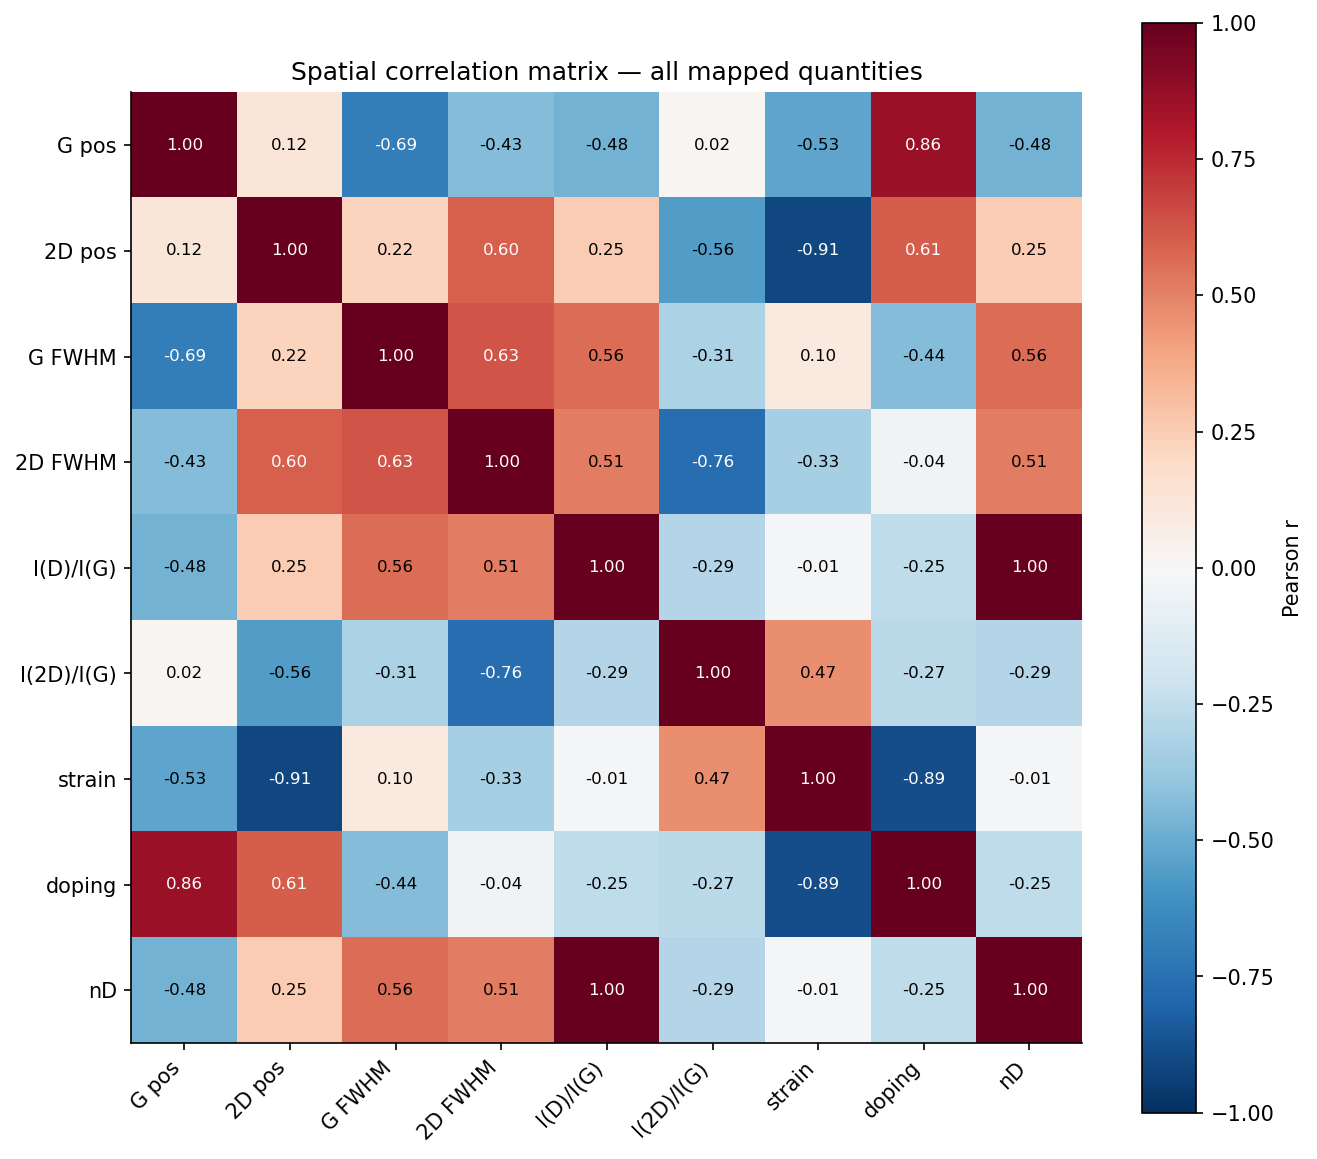

In [65]:
# All map quantities stacked
quantities = {
    "G pos"     : map_g_cen,
    "2D pos"    : map_td_cen,
    "G FWHM"    : map_g_fwhm,
    "2D FWHM"   : map_td_fwhm_envelope,
    "I(D)/I(G)" : map_ratio_dg_amp,
    "I(2D)/I(G)": map_ratio_2dg_amp,
    "strain"    : map_strain_pct,
    "doping"    : map_doping_n13,
    "nD"        : map_nD1,
}

# Build correlation matrix
import pandas as pd
df   = pd.DataFrame({k: v for k, v in quantities.items()
                     if not np.all(np.isnan(v))})
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i,j]) > 0.6 else "black")
ax.set_title("Spatial correlation matrix — all mapped quantities")
plt.tight_layout()
plt.savefig("map_correlation_matrix.png", dpi=150, bbox_inches="tight")

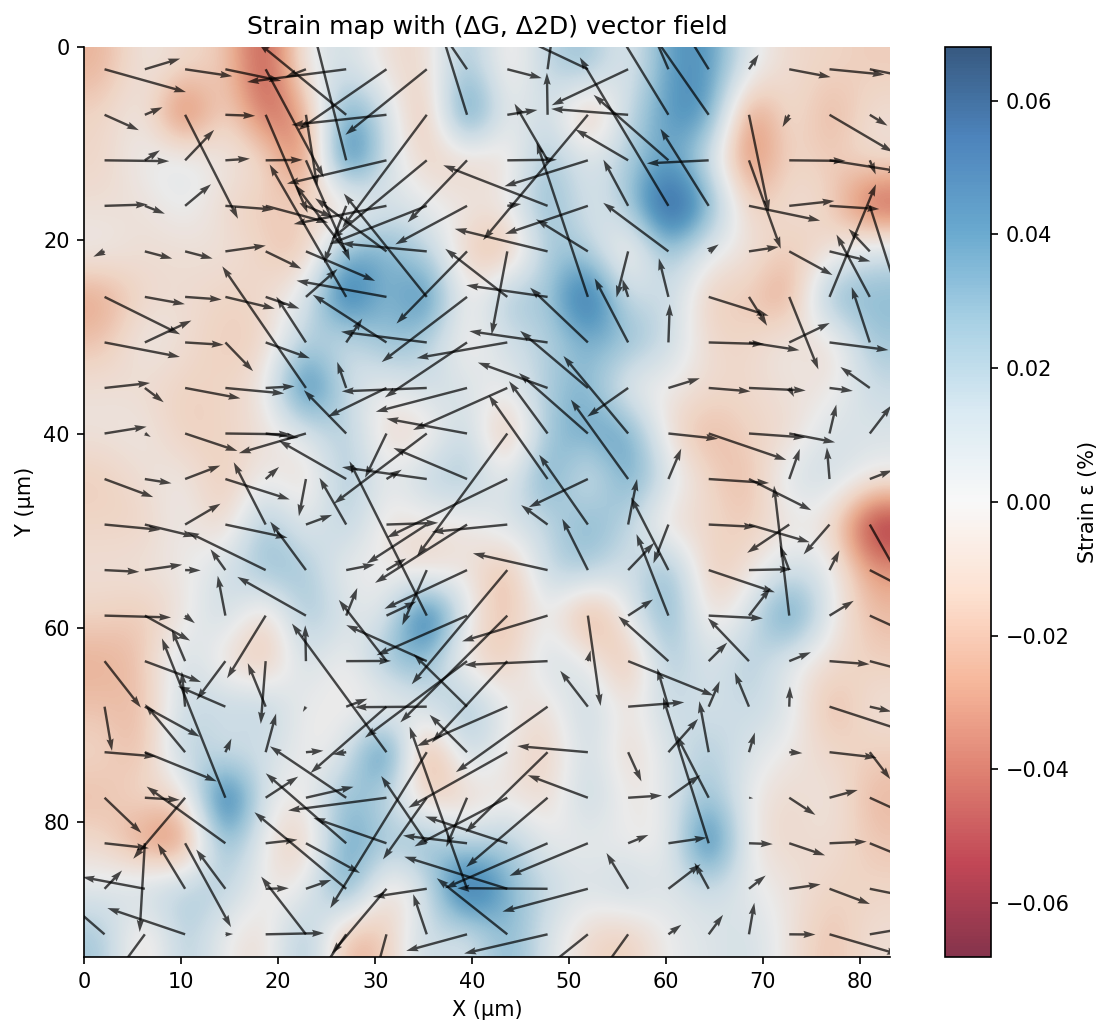

In [66]:
# Vector field of strain direction
NX, NY = 20, 20
X = np.arange(NX) * STEP_X_UM + STEP_X_UM/2
Y = np.arange(NY) * STEP_Y_UM + STEP_Y_UM/2
XX, YY = np.meshgrid(X, Y)

# Strain component gives arrow magnitude, direction is always along X
# (we only have scalar strain from biaxial assumption)
# More interesting: plot raw (ΔG, Δ2D) as vectors
UU = g_deviation.reshape(NY, NX)    # G shift → x-component
VV = td_deviation.reshape(NY, NX)   # 2D shift → y-component

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_strain_pct)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="RdBu",
               vmin=-s_lim, vmax=s_lim,
               interpolation="bicubic", alpha=0.8)
ax.quiver(XX, YY, UU, -VV,   # flip VV for image coordinates
          scale=50, width=0.003,
          color="black", alpha=0.7)
plt.colorbar(im, ax=ax, label="Strain ε (%)")
ax.set_title("Strain map with (ΔG, Δ2D) vector field")
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")
plt.tight_layout()
plt.savefig("map06_strain_vectors.png", dpi=150, bbox_inches="tight")